# MMMU-Pro Eval300 × InternVL3.5-8B Q4_K_M — P3 Two-Call Plan-and-Solve

**Production, paper-oriented, resume-safe P3 evaluation notebook**

This notebook implements the same **P3 two-call Plan-and-Solve protocol** as the
uploaded P3 reference notebook, adapted only for the previously saved local
InternVL3.5-8B Q4_K_M GGUF bundle.

For every MMMU-Pro sample:

1. **Call 1 — planning:** the complete multimodal question and all options are sent
   with the exact trigger:

   `A: Let's first understand the problem and devise a plan to solve the problem.`

2. The raw visible Call-1 response is checkpointed and injected **verbatim** into
   Call 2.

3. **Call 2 — execution/final answer:** the complete multimodal question and images
   are sent again, followed by the stored plan and:

   ```text
   Answer the preceding multiple choice question.
   The last line of your response should be of the following format:
   'Answer: $LETTER' (without quotes) where LETTER is one of options.
   let's carry out the plan and solve the problem step by step.
   Explain your reasoning before answering.
   ```

Only Call 2 is scored.

The model, projector, and llama runtime are loaded from the same local Kaggle
Input layout used by the previous P3/P3 notebooks. The runtime under
`/kaggle/input` is **never executed directly**: its verified bytes are always
copied to `/kaggle/temp/internvl35_8b_local_runtime/llama`, chmod is applied only to the writable copy,
and SHA-256 is rechecked before use. This prevents both read-only and `noexec`
Kaggle mount failures.

Both calls use `MAX_TOKENS=8192`, `CTX_SIZE=16384`, temperature `0.0`, seed `42`,
and no explicit top-p/top-k. No Qwen-specific `enable_thinking` request parameter is sent to InternVL. The llama transport/parser still uses `--reasoning off`.


## Revision note — reconstruct Eval300 from a frozen ordered ID list

The evaluation subset is reconstructed from the official Hugging Face source:

```text
MMMU/MMMU_Pro / standard (10 options) / test
```

at the exact immutable source revision:

```text
563f3e84bb3b90893083a1f039cfa13077f2302b
```

The notebook first downloads all 1,730 rows in this source setting and then
performs exact ID lookup using `selected_ids.txt`. There is no re-sampling,
nearest-match lookup, question-text matching, or subject-based replacement.

The line order of `selected_ids.txt` is the evaluation order. Candidate options
are preserved row-faithfully:

- answer letters are derived dynamically from each row's actual option count;
- every option is preserved exactly as published;
- no option is padded, truncated, invented, or rewritten;
- every gold label must be valid for the row's actual choice set;
- the selected option-count distribution is archived.

Because the inference notebook receives only the frozen ID list (not the
few-shot pool), it does **not** claim to independently recompute few-shot
disjointness. That property belongs to the upstream dataset-construction stage.
This notebook instead proves that it evaluates the exact cryptographically
pinned ID list produced by that stage.


## Fixed P3 generation protocol

The experimental variable is **P3 Two-Call Plan-and-Solve**. Both calls use the
same model, image-occurrence order, decoding settings, local runtime, and frozen
Eval300 cohort.

- Call 1 receives the complete multimodal problem and produces one plan.
- The raw Call-1 visible response is injected verbatim into Call 2.
- Call 2 receives the complete multimodal problem again plus the stored plan.
- Only Call 2 is scored.
- Repeated image references remain repeated at every marker occurrence.
- A valid HTTP 200 response is checkpointed once and is not regenerated because
  of content quality, plan leakage, formatting, or truncation.
- `PLAN_MAX_TOKENS = ANSWER_MAX_TOKENS = 8192`.
- `CTX_SIZE = 16384`.


# 0. Kaggle resume protocol — P3

Attach the same local model bundle used previously:

```text
internvl35_8b_saved/InternVL3_5-8B-Q4_K_M.gguf
internvl35_8b_saved/mmproj-model-f16.gguf
internvl35_llama_runtime/llama  (preferred)
llama_runtime/llama             (accepted fallback)
```

Also attach the frozen `selected_ids.txt` and use **2× NVIDIA T4**.

The notebook:
- verifies exact model/projector/runtime SHA-256 identities,
- always executes the llama runtime from a verified writable `/kaggle/temp` copy,
- checkpoints Call 1 plans and Call 2 final answers independently,
- resumes only from an exact P3 experiment signature,
- validates the exact injected plan hash before accepting a saved final answer.

No model/projector/runtime download fallback is used.


# 1. Install only missing lightweight Python packages


In [1]:
import importlib.util, subprocess, sys

requirements = {
    "datasets": "datasets>=3.0",
    "huggingface_hub": "huggingface_hub>=0.24",
    "requests": "requests>=2.31",
    "sklearn": "scikit-learn>=1.3",
    "statsmodels": "statsmodels>=0.14",
    "PIL": "Pillow>=10",
    "pandas": "pandas>=2",
    "numpy": "numpy>=1.26",
    "matplotlib": "matplotlib>=3.8",
}

to_install = [
    spec for mod, spec in requirements.items()
    if importlib.util.find_spec(mod) is None
]

if to_install:
    print("Installing only missing lightweight packages:", to_install)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *to_install]
    )
else:
    print("All required Python packages already available.")

print("No model/runtime/MMMU-Pro download was performed by this cell.")


All required Python packages already available.
No model/runtime/MMMU-Pro download was performed by this cell.


# 2. Frozen P3 experimental configuration

This cell freezes the **P3** experiment identity, local InternVL3.5-8B Q4_K_M artifact
identity, Eval300 cohort, two-call generation settings, local-runtime policy, and
resume/output paths.


In [2]:
import os, io, re, ast, json, time, math, base64, random, string, shutil
import hashlib, html, platform, subprocess, sys, shlex, threading, logging, importlib.metadata
from pathlib import Path
from datetime import datetime, timezone
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from PIL import Image
from tqdm.auto import tqdm
from datasets import load_dataset, Image as HFImage
from huggingface_hub import snapshot_download
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, f1_score,
    balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score,
    confusion_matrix,
)
from statsmodels.stats.proportion import proportion_confint


EXPERIMENT_ID = (
    "MMMUPro-Eval300__InternVL3.5-8B-Q4_K_M__P3-TwoCallPlanAndSolve__"
    "LocalLlamaCpp__RawPlanInjection__ValidatedTwoStageResume__"
    "Temperature0__Seed42__MAX8192__CTX16384"
)

PROMPT_ID = "P3-TwoCallPlanAndSolve"
PROMPT_FAMILY = "Two-call Plan-and-Solve with raw plan injection"
EVALUATION_COHORT_ID = "MMMUPro-frozen-balanced-eval300-v1"

MODEL = "InternVL3.5-8B-Q4_K_M"
MODEL_API_NAME = "internvl3.5-8b"
BASE_MODEL = "OpenGVLab/InternVL3_5-8B"
MODEL_ARCHITECTURE = "InternVL3.5-8B multimodal model"
MODEL_REPO = "lmstudio-community/InternVL3_5-8B-GGUF"
QUANTIZATION = "Q4_K_M"
MODEL_FILENAME = "InternVL3_5-8B-Q4_K_M.gguf"
MMPROJ_FILENAME = "mmproj-model-f16.gguf"
MMPROJ_PRECISION = "F16"
MODEL_SHA256 = "2809043479b8d3aab30378766c7a2a4bd93eedd97c86efc6d65d627fd680faba"
MMPROJ_SHA256 = "212cc090f81ea2981b870186d4b424fae69489a5313a14e52ffdb2e877852389"
MODEL_ARTIFACT_REVISION = "ae2ec0fbf3e4abb20a33e9d682c5ebf33f638ab7"
MMPROJ_ARTIFACT_REVISION = "98b41ac52d1cfb464694a45faab81ab685ad2dfb"

PROVIDER = "local llama.cpp"
API_METHOD = "OpenAI-compatible /v1/chat/completions"
API_MODE = "local stateless HTTP"
API_VERSION = "v1"
SDK_PACKAGE = "requests"
SDK_VERSION_PIN = None
SDK_PIN = "llama.app build 10679 commit 50f068fff; exact local binary SHA-256 pinned"
LLAMA_CPP_COMMIT = "50f068fff"
LLAMA_RUNTIME_SHA256 = "29cf4dddaad7d8249546e1258e553e12435749345db37905a5dd0c5c35e3e36f"
LLAMA_RUNTIME_POLICY = (
    "use only the attached local llama runtime; verify exact SHA-256 and "
    "build-10679 / 50f068fff identity; always execute a byte-identical "
    "working copy under /kaggle/temp to avoid read-only/noexec input mounts"
)

INPUT_ROOT = Path("/kaggle/input")
LOCAL_MODEL_DIRNAME = "internvl35_8b_saved"
LOCAL_RUNTIME_DIRNAME = "internvl35_llama_runtime"
LOCAL_MANIFEST_FILENAME = "model_manifest.json"

DATASET_REPO = "MMMU/MMMU_Pro"
DATASET_CONFIG = "standard (10 options)"
DATASET_SUBDIR = "standard (10 options)"
DATASET_SPLIT = "test"
DATASET_REVISION = "563f3e84bb3b90893083a1f039cfa13077f2302b"
REVISION_SOURCE = "hard-pinned full Hugging Face commit SHA"
EXPECTED_SOURCE_N = 1730
EXPECTED_N = 300

EXPECTED_SOURCE_OPTION_COUNT_DISTRIBUTION = {
    2: 28, 3: 42, 4: 125, 5: 41, 6: 16, 7: 12,
    8: 31, 9: 221, 10: 1213, 12: 1,
}

SELECTION_PROTOCOL_NAME = (
    "fixed ordered selected_ids.txt; exact ID extraction from pinned official "
    "MMMU-Pro standard (10 options) test source; no resampling"
)
EXPECTED_SELECTED_IDS_CANONICAL_SHA256 = (
    "db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3"
)

INPUT_ROOT = Path("/kaggle/input")
if not INPUT_ROOT.exists():
    raise RuntimeError("/kaggle/input is missing; this notebook is intended for Kaggle.")


def canonical_id_text(ids):
    return "\n".join(ids) + "\n"


def canonical_id_sha256(ids):
    return hashlib.sha256(canonical_id_text(ids).encode("utf-8")).hexdigest()


def read_id_file_strict(path):
    text = Path(path).read_text(encoding="utf-8")
    lines = text.splitlines()

    if any((not line) or line != line.strip() for line in lines):
        raise RuntimeError(
            f"ID file contains blank lines or surrounding whitespace: {path}"
        )

    return lines, hashlib.sha256(Path(path).read_bytes()).hexdigest()


# Accept duplicate copies only if they resolve to the exact frozen ordered list.
all_selected_id_files = sorted({
    p.resolve()
    for p in INPUT_ROOT.rglob("selected_ids.txt")
    if p.is_file()
})

matching_id_files = []
id_file_diagnostics = []

for p in all_selected_id_files:
    try:
        ids_here, raw_sha_here = read_id_file_strict(p)
        canonical_sha_here = canonical_id_sha256(ids_here)
        id_file_diagnostics.append({
            "path": str(p),
            "rows": len(ids_here),
            "unique_rows": len(set(ids_here)),
            "raw_sha256": raw_sha_here,
            "canonical_sha256": canonical_sha_here,
        })
        if canonical_sha_here == EXPECTED_SELECTED_IDS_CANONICAL_SHA256:
            matching_id_files.append((p, ids_here, raw_sha_here))
    except Exception as e:
        id_file_diagnostics.append({
            "path": str(p),
            "error": repr(e),
        })

if not matching_id_files:
    raise RuntimeError(
        "No uploaded selected_ids.txt matches the frozen 300-ID selection.\n"
        f"Expected canonical SHA256: {EXPECTED_SELECTED_IDS_CANONICAL_SHA256}\n"
        f"Discovered files: {json.dumps(id_file_diagnostics, ensure_ascii=False, indent=2)}"
    )

# Multiple matching copies are scientifically equivalent; choose a stable path.
matching_id_files.sort(key=lambda x: str(x[0]))
SELECTED_IDS_PATH, selected_ids, SELECTED_IDS_RAW_SHA256 = matching_id_files[0]
SELECTED_IDS_CANONICAL_SHA256 = canonical_id_sha256(selected_ids)

if len(selected_ids) != EXPECTED_N:
    raise RuntimeError(
        f"selected_ids.txt rows={len(selected_ids)} != {EXPECTED_N}"
    )
if len(set(selected_ids)) != EXPECTED_N:
    raise RuntimeError("selected_ids.txt contains duplicate IDs.")

_id_pattern = re.compile(r"^(test|validation)_(.+)_([0-9]+)$")
id_subject_tokens = []
for sid in selected_ids:
    m = _id_pattern.fullmatch(sid)
    if not m:
        raise RuntimeError(f"Unexpected MMMU ID format: {sid!r}")
    id_subject_tokens.append(m.group(2))

id_subject_counts = Counter(id_subject_tokens)
if len(id_subject_counts) != 30:
    raise RuntimeError(
        f"Expected 30 subject tokens in selected_ids.txt; got {len(id_subject_counts)}"
    )
if set(id_subject_counts.values()) != {10}:
    raise RuntimeError(
        f"selected_ids.txt is not exactly 10 IDs per subject: {dict(id_subject_counts)}"
    )

if SELECTED_IDS_CANONICAL_SHA256 != EXPECTED_SELECTED_IDS_CANONICAL_SHA256:
    raise RuntimeError("Internal selected-ID canonical hash mismatch.")


API_SEED = 42
SEED_POLICY = "fixed_seed_all_requests_v1"

PROTOCOL_VERSION = "P3_TWO_CALL_PLAN_AND_SOLVE_INTERNVL35_8B_LOCAL_EVAL300_RESUMESAFE_MAX8192_CTX16384_V1"
PARSER_VERSION = "deterministic_final_line_answer_v1"
LOGGING_VERSION = "p3_two_stage_local_live_per_request_full_error_v1"
SCHEDULING_VERSION = "p3_two_stage_local_preflight_defer_timeout_then_long_retry_v1"
IMAGE_ENCODING_POLICY = "lossless_png_local_data_url_v1"
IMAGE_ORDER_POLICY = (
    "MMMU-Pro marker occurrence order in both calls; each occurrence emits its "
    "semantic label followed immediately by the matching image; repeated references repeat the image"
)
PLAN_UNIT_POLICY = "one successful planning call per sample_id"
PLAN_INJECTION_POLICY = "raw visible call-1 response injected verbatim into call 2"

TEMPERATURE = 0.0
TOP_P = None
TOP_K = None
MAX_TOKENS = 8192
PLAN_MAX_TOKENS = MAX_TOKENS
ANSWER_MAX_TOKENS = MAX_TOKENS
CTX_SIZE = 16384
CTX_SIZE_POLICY = "explicit local llama.cpp server --ctx-size 16384 with --parallel 1"
STREAM = False
NATIVE_THINKING = False
THINKING_LEVEL = None
REQUEST_ENABLE_THINKING = None
STRICT_NATIVE_REASONING_EMPTY = False
THINKING_MODE_POLICY = 'InternVL default mode; no model-specific thinking request parameter is sent; llama reasoning parser disabled with --reasoning off; any reasoning-like output is diagnostic only'
REQUEST_SEED = API_SEED
TENSOR_SPLIT = "1,1"
PORT = 8080

assert TEMPERATURE == 0.0
assert TOP_P is None and TOP_K is None
assert API_SEED == 42
assert MAX_TOKENS == 8192
assert PLAN_MAX_TOKENS == ANSWER_MAX_TOKENS == MAX_TOKENS
assert CTX_SIZE == 16384
assert NATIVE_THINKING is False
assert THINKING_LEVEL is None

REQUEST_TIMEOUT_S = 1800
DEFERRED_REQUEST_TIMEOUT_S = 7200
REQUEST_TIMEOUT_MS = REQUEST_TIMEOUT_S * 1000
DEFERRED_REQUEST_TIMEOUT_MS = DEFERRED_REQUEST_TIMEOUT_S * 1000
SDK_INTERNAL_RETRY_ATTEMPTS = 0
MAX_ATTEMPTS = 2
DEFERRED_MAX_ATTEMPTS = 2
BASE_BACKOFF_S = 5.0
MAX_BACKOFF_S = 30.0
INTER_REQUEST_DELAY_S = 0.0
RETRYABLE_STATUS = {408, 409, 429, 500, 502, 503, 504}
DEFERRED_RETRY_PASSES = 1
MAX_CONSECUTIVE_EXHAUSTED_429 = 3
MAX_TOTAL_SERVER_RESTARTS = 100
SOFT_WALLCLOCK_HOURS = 10.5

ARCHIVE_IMAGES = True
GENERATE_HTML_AUDIT = True
N_BOOTSTRAP = 2000
PRICE_INPUT_PER_1M_USD = 0.0
PRICE_OUTPUT_PER_1M_USD = 0.0

WORKDIR = Path('/kaggle/working/internvl35_8b_p3_two_call_plan_solve_eval300_MAX8192_CTX16384_localinput_v1')
MEDIA_DIR = WORKDIR / "media"
PLOTS_DIR = WORKDIR / "plots"
SOURCE_CACHE_ROOT = Path("/kaggle/working/mmmu_pro_source_pinned_563f3e84")

for p in (WORKDIR, MEDIA_DIR, PLOTS_DIR, SOURCE_CACHE_ROOT):
    p.mkdir(parents=True, exist_ok=True)

RAW = WORKDIR / "raw_results.jsonl"
PLAN_RAW = WORKDIR / "plan_results.jsonl"
EVENTS = WORKDIR / "api_events.jsonl"
SESSIONS = WORKDIR / "run_sessions.jsonl"
MANIFEST = WORKDIR / "run_manifest.json"
DSET_CSV = WORKDIR / "dataset_manifest.csv"
DSET_JSONL = WORKDIR / "dataset_manifest.jsonl"
INTEGRITY_JSON = WORKDIR / "dataset_integrity_audit.json"
SOURCE_PROVENANCE_JSON = WORKDIR / "source_dataset_provenance.json"
SELECTED_IDS_AUDIT_JSON = WORKDIR / "selected_ids_audit.json"
SELECTED_IDS_ARCHIVE = WORKDIR / "selected_ids.txt"
RESULTS_CSV = WORKDIR / "results_all.csv"
RESULTS_PARQUET = WORKDIR / "results_all.parquet"
PLAN_RESULTS_CSV = WORKDIR / "plans_all.csv"
ERROR_ANALYSIS_CSV = WORKDIR / "wrong_results_for_error_analysis.csv"
PARSER_AUDIT_CSV = WORKDIR / "parser_audit.csv"
SUMMARY_JSON = WORKDIR / "summary_metrics.json"
SUMMARY_CSV = WORKDIR / "summary_metrics.csv"
CLASS_CSV = WORKDIR / "class_metrics_all_choice_letters.csv"
SUBJECT_CSV = WORKDIR / "accuracy_by_subject.csv"
DOMAIN_CSV = WORKDIR / "accuracy_by_domain.csv"
DIFF_CSV = WORKDIR / "accuracy_by_difficulty.csv"
IMGTYPE_CSV = WORKDIR / "accuracy_by_image_type.csv"
IMGCOUNT_CSV = WORKDIR / "accuracy_by_image_count.csv"
AUDIT_HTML = WORKDIR / "audit_viewer.html"
README = WORKDIR / "README_RESULTS.md"
ENV_JSON = WORKDIR / "environment.json"
PIP_TXT = WORKDIR / "pip_freeze.txt"
MODEL_INFO_JSON = WORKDIR / "internvl35_8b_p3_local_model_info.json"
PREFLIGHT_JSON = WORKDIR / "api_preflight.json"
DEFERRED_QUEUE_JSON = WORKDIR / "deferred_queue.json"
MISSING_IDS_TXT = WORKDIR / "missing_ids.txt"
MISSING_PLAN_IDS_JSON = WORKDIR / "missing_plan_ids.json"
CHECKPOINT_REPAIR_AUDIT = WORKDIR / "checkpoint_repair_audit.jsonl"

ALL_LETTERS = list(string.ascii_uppercase)
IMAGE_COLS = [f"image_{i}" for i in range(1, 8)]

# Archive the exact canonical ordered ID list used by this experiment.
SELECTED_IDS_ARCHIVE.write_text(
    canonical_id_text(selected_ids),
    encoding="utf-8",
)
selected_ids_audit = {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "selected_ids_input_path": str(SELECTED_IDS_PATH),
    "matching_input_copies": [str(x[0]) for x in matching_id_files],
    "discovered_id_file_diagnostics": id_file_diagnostics,
    "rows": len(selected_ids),
    "unique_rows": len(set(selected_ids)),
    "raw_input_sha256": SELECTED_IDS_RAW_SHA256,
    "canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "expected_canonical_sha256": EXPECTED_SELECTED_IDS_CANONICAL_SHA256,
    "order_policy": "line order of canonical selected_ids.txt",
    "subject_token_counts": dict(sorted(id_subject_counts.items())),
}
SELECTED_IDS_AUDIT_JSON.write_text(
    json.dumps(selected_ids_audit, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

SESSION_START_MONO = time.monotonic()
SESSION_START_UTC = datetime.now(timezone.utc).isoformat()

logger = logging.getLogger("internvl35_8b_eval300_p3_local")
logger.setLevel(logging.INFO)
logger.handlers.clear()
_fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
_fh = logging.FileHandler(WORKDIR / "run.log", mode="a", encoding="utf-8")
_fh.setFormatter(_fmt)
logger.addHandler(_fh)
_sh = logging.StreamHandler(sys.stdout)
_sh.setFormatter(_fmt)
logger.addHandler(_sh)

print(EXPERIMENT_ID)
print("selected_ids input:", SELECTED_IDS_PATH)
print("selected_ids rows:", len(selected_ids))
print("selected_ids canonical SHA256:", SELECTED_IDS_CANONICAL_SHA256)
print("Matching identical selected_ids copies:", len(matching_id_files))
print("Output:", WORKDIR)


MMMUPro-Eval300__InternVL3.5-8B-Q4_K_M__P3-TwoCallPlanAndSolve__LocalLlamaCpp__RawPlanInjection__ValidatedTwoStageResume__Temperature0__Seed42__MAX8192__CTX16384
selected_ids input: /kaggle/input/datasets/zahranafe/300-mmmu-pro/selected_ids.txt
selected_ids rows: 300
selected_ids canonical SHA256: db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
Matching identical selected_ids copies: 1
Output: /kaggle/working/internvl35_8b_p3_two_call_plan_solve_eval300_MAX8192_CTX16384_localinput_v1


# 3. Discover and verify the local InternVL3.5-8B Q4_K_M bundle

The model and projector are read from the same prior Kaggle Input layout. The
attached llama binary is treated as provenance-only and is never executed
directly from `/kaggle/input`.

Before `version`, `--list-devices`, or `serve`, the exact verified runtime bytes
are copied to:

`/kaggle/temp/internvl35_8b_local_runtime/llama`

The copy is chmod'd and SHA-256 is verified again. This explicitly handles both
Kaggle read-only and `noexec` input mounts.


In [3]:

def sha_file(p, chunk_size=16 * 1024 * 1024):
    h = hashlib.sha256()
    with Path(p).open("rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


def gguf_ok(path):
    path = Path(path)
    if not path.is_file():
        return False
    try:
        with path.open("rb") as f:
            return f.read(4) == b"GGUF"
    except Exception:
        return False


def kaggle_source_root(path):
    p = Path(path).resolve()
    parts = p.parts
    try:
        i = parts.index("input")
    except ValueError:
        return p.parent
    if len(parts) > i + 1 and parts[i + 1] == "notebooks" and len(parts) > i + 3:
        return Path(*parts[:i + 4])
    if len(parts) > i + 1:
        return Path(*parts[:i + 2])
    return p.parent


gpu_lines = subprocess.check_output(
    ["nvidia-smi", "--query-gpu=index,name,memory.total,compute_cap", "--format=csv,noheader"],
    text=True,
).strip().splitlines()
gpu_names = [
    x.strip()
    for x in subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"], text=True
    ).strip().splitlines()
]
compute_caps = [
    float(v.strip())
    for v in subprocess.check_output(
        ["nvidia-smi", "--query-gpu=compute_cap", "--format=csv,noheader,nounits"],
        text=True,
    ).strip().splitlines()
    if v.strip()
]
if len(gpu_names) != 2 or not all("T4" in name.upper() for name in gpu_names):
    raise RuntimeError(f"Frozen protocol requires exactly 2× NVIDIA T4; detected {gpu_names}")
if compute_caps != [7.5, 7.5]:
    raise RuntimeError(f"Expected compute capability [7.5, 7.5]; got {compute_caps}")
print("✅ Hardware gate passed:", gpu_lines)


model_candidates = sorted({
    p.resolve()
    for p in INPUT_ROOT.rglob(MODEL_FILENAME)
    if p.is_file() and p.parent.name == LOCAL_MODEL_DIRNAME
}, key=str)

if not model_candidates:
    relevant = []
    for p in INPUT_ROOT.rglob("*"):
        try:
            if p.is_file() and (
                p.suffix.lower() == ".gguf" or p.name in {"llama", "model_manifest.json"}
            ):
                relevant.append(str(p.resolve()))
        except Exception:
            pass
    raise FileNotFoundError(
        "Could not find local InternVL3.5-8B model bundle.\n"
        f"Expected suffix: {LOCAL_MODEL_DIRNAME}/{MODEL_FILENAME}\n"
        "Relevant discovered files:\n"
        + ("\n".join(relevant[:250]) if relevant else "<none>")
    )


bundle_diagnostics = []
valid_bundles = []

for model_path in model_candidates:
    model_dir = model_path.parent
    source_root = kaggle_source_root(model_path)
    mmproj = (model_dir / MMPROJ_FILENAME).resolve()
    manifest = (model_dir / LOCAL_MANIFEST_FILENAME).resolve()

    preferred_runtime_candidates = [
        source_root / "internvl35_llama_runtime" / "llama",
        source_root / "llama_runtime" / "llama",
    ]
    discovered_runtime_candidates = []
    try:
        for p in source_root.rglob("llama"):
            if p.is_file() and "llama_runtime" in p.parent.name.lower():
                discovered_runtime_candidates.append(p.resolve())
    except Exception:
        pass

    runtime_candidates = sorted({
        Path(p).resolve()
        for p in preferred_runtime_candidates + discovered_runtime_candidates
        if Path(p).is_file() and kaggle_source_root(p) == source_root
    }, key=str)

    diag = {
        "source_root": str(source_root),
        "model_path": str(model_path),
        "mmproj_path": str(mmproj),
        "manifest_path": str(manifest),
        "runtime_candidates": [str(p) for p in runtime_candidates],
    }

    model_sha = sha_file(model_path) if gguf_ok(model_path) else None
    mmproj_sha = sha_file(mmproj) if gguf_ok(mmproj) else None
    diag["model_sha256"] = model_sha
    diag["model_matches_expected_sha"] = (model_sha == MODEL_SHA256)
    diag["mmproj_sha256"] = mmproj_sha
    diag["mmproj_matches_expected_sha"] = (mmproj_sha == MMPROJ_SHA256)

    if manifest.is_file():
        try:
            diag["manifest_json_ok"] = True
            diag["manifest"] = json.loads(manifest.read_text(encoding="utf-8"))
        except Exception as exc:
            diag["manifest_json_ok"] = False
            diag["manifest_error"] = repr(exc)

    verified_runtimes = []
    for runtime in runtime_candidates:
        rt = {"path": str(runtime), "sha256": sha_file(runtime)}
        rt["matches_expected_sha"] = (rt["sha256"] == LLAMA_RUNTIME_SHA256)
        if not rt["matches_expected_sha"]:
            diag.setdefault("runtime_diagnostics", []).append(rt)
            continue

        # Kaggle /kaggle/input can be mounted with `noexec`. A runtime may have
        # executable mode bits and still fail with PermissionError when launched.
        # Therefore ALWAYS execute a byte-identical writable copy from /kaggle/temp.
        runtime_copy_dir = Path("/kaggle/temp/internvl35_8b_local_runtime")
        runtime_copy_dir.mkdir(parents=True, exist_ok=True)
        runtime_for_exec = (runtime_copy_dir / "llama").resolve()

        shutil.copy2(runtime, runtime_for_exec)
        os.chmod(runtime_for_exec, 0o755)

        copied_sha = sha_file(runtime_for_exec)
        if copied_sha != rt["sha256"]:
            raise RuntimeError(
                "Writable llama runtime copy changed bytes: "
                f"{copied_sha} != {rt['sha256']}"
            )

        ver_proc = subprocess.run(
            [str(runtime_for_exec), "version"],
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            check=False,
        )
        version_here = ver_proc.stdout or ""
        rt["version"] = version_here.strip()
        rt["version_ok"] = ("10679" in version_here or "50f068fff" in version_here)

        dev_proc = subprocess.run(
            [str(runtime_for_exec), "serve", "--list-devices"],
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            check=False,
            env={**os.environ, "CUDA_VISIBLE_DEVICES": "0,1"},
        )
        dev_text = dev_proc.stdout or ""
        cuda_here = [
            line.strip()
            for line in dev_text.splitlines()
            if line.strip().lower().startswith("cuda")
        ]
        rt["cuda_lines"] = cuda_here
        rt["cuda_ok"] = len(cuda_here) >= 2
        rt["exec_path"] = str(runtime_for_exec)
        rt["used_writable_copy"] = True
        diag.setdefault("runtime_diagnostics", []).append(rt)

        if rt["version_ok"] and rt["cuda_ok"]:
            verified_runtimes.append({
                "path": runtime_for_exec,
                "input_path": runtime,
                "sha": rt["sha256"],
                "version": version_here,
                "cuda_lines": cuda_here,
            })

    bundle_diagnostics.append(diag)

    if model_sha == MODEL_SHA256 and mmproj_sha == MMPROJ_SHA256 and verified_runtimes:
        verified_runtimes.sort(
            key=lambda rec: (
                0 if rec["input_path"].parent.name == "internvl35_llama_runtime" else 1,
                str(rec["path"]),
            )
        )
        rt = verified_runtimes[0]
        valid_bundles.append({
            "source_root": source_root,
            "model_path": model_path,
            "mmproj_path": mmproj,
            "manifest_path": manifest if manifest.is_file() else None,
            "runtime_input_path": rt["input_path"],
            "runtime_path": rt["path"],
            "model_sha": model_sha,
            "mmproj_sha": mmproj_sha,
            "runtime_sha": rt["sha"],
            "runtime_version": rt["version"],
            "cuda_lines": rt["cuda_lines"],
        })


if len(valid_bundles) != 1:
    inventory = []
    try:
        for p in INPUT_ROOT.rglob("*"):
            if p.is_file() and (
                p.suffix.lower() == ".gguf" or p.name in {"llama", "model_manifest.json"}
            ):
                inventory.append(str(p.resolve()))
    except Exception:
        pass
    raise RuntimeError(
        "Expected exactly one SHA-verified InternVL3.5-8B local input bundle. "
        f"Found {len(valid_bundles)}.\n"
        "Bundle diagnostics:\n"
        + json.dumps(bundle_diagnostics, ensure_ascii=False, indent=2)
        + "\nRelevant /kaggle/input inventory:\n"
        + ("\n".join(inventory[:300]) if inventory else "<none>")
    )


selected = valid_bundles[0]
MODEL_PATH = Path(selected["model_path"]).resolve()
MMPROJ_PATH = Path(selected["mmproj_path"]).resolve()
LLAMA_INPUT_PATH = Path(selected["runtime_input_path"]).resolve()
LLAMA_BIN = Path(selected["runtime_path"]).resolve()
SAVED_LLAMA = LLAMA_BIN

MODEL_SHA_OBSERVED = selected["model_sha"]
MMPROJ_SHA_OBSERVED = selected["mmproj_sha"]
LLAMA_SHA_OBSERVED = selected["runtime_sha"]
version_text = selected["runtime_version"]
cuda_lines = selected["cuda_lines"]

MODEL_INPUT_ROOT = Path(selected["source_root"]).resolve()
PREFERRED_MODEL_PATH = MODEL_PATH
MODEL_SOURCE = "local_kaggle_input_sha_verified"
MMPROJ_REPO = MODEL_REPO
MMPROJ_REVISION = MMPROJ_ARTIFACT_REVISION
MMPROJ_SOURCE = "local_kaggle_input_sha_verified"
LLAMA_RUNTIME_SOURCE = "local_kaggle_input_exact_build10679_sha_verified"
LLAMA_INSTALLER_SHA256 = None
INSTALL_LOG = None

assert MODEL_SHA_OBSERVED == MODEL_SHA256
assert MMPROJ_SHA_OBSERVED == MMPROJ_SHA256
assert LLAMA_SHA_OBSERVED == LLAMA_RUNTIME_SHA256
assert sha_file(LLAMA_BIN) == LLAMA_RUNTIME_SHA256

print("\n✅ Local InternVL3.5-8B bundle verified")
print("Kaggle source root:", MODEL_INPUT_ROOT)
print("Model             :", MODEL_PATH)
print("Model SHA256      :", MODEL_SHA_OBSERVED)
print("Projector         :", MMPROJ_PATH)
print("Projector SHA256  :", MMPROJ_SHA_OBSERVED)
print("Runtime input     :", LLAMA_INPUT_PATH)
print("Runtime exec      :", LLAMA_BIN)
print("Runtime SHA256    :", LLAMA_SHA_OBSERVED)
print("Runtime version   :", version_text.strip())
print("CUDA devices      :", cuda_lines)


✅ Hardware gate passed: ['0, Tesla T4, 15360 MiB, 7.5', '1, Tesla T4, 15360 MiB, 7.5']

✅ Local InternVL3.5-8B bundle verified
Kaggle source root: /kaggle/input/notebooks/vernvern/notebookf785af4a9b
Model             : /kaggle/input/notebooks/vernvern/notebookf785af4a9b/internvl35_8b_saved/InternVL3_5-8B-Q4_K_M.gguf
Model SHA256      : 2809043479b8d3aab30378766c7a2a4bd93eedd97c86efc6d65d627fd680faba
Projector         : /kaggle/input/notebooks/vernvern/notebookf785af4a9b/internvl35_8b_saved/mmproj-model-f16.gguf
Projector SHA256  : 212cc090f81ea2981b870186d4b424fae69489a5313a14e52ffdb2e877852389
Runtime input     : /kaggle/input/notebooks/vernvern/notebookf785af4a9b/internvl35_llama_runtime/llama
Runtime exec      : /kaggle/temp/internvl35_8b_local_runtime/llama
Runtime SHA256    : 29cf4dddaad7d8249546e1258e553e12435749345db37905a5dd0c5c35e3e36f
Runtime version   : version: 0.3.0-dev (build 10679, commit 50f068fff)
built with GNU 12.3.0 for Linux x86_64
CUDA devices      : ['CUDA0: Tesl

# 4. Frozen P3 templates and immutable inference signature

The exact P3 prompt strings and their SHA-256 hashes are frozen here. Call 1 is
planning-only; Call 2 repeats the complete multimodal problem, injects the raw
Call-1 plan verbatim, then applies the fixed execution/final-answer scaffold.


In [4]:
PLAN_SUFFIX = "A: Let's first understand the problem and devise a plan to solve the problem."
EXECUTION_SUFFIX = "Answer the preceding multiple choice question.\nThe last line of your response should be of the following format:\n'Answer: $LETTER' (without quotes) where LETTER is one of options.\nlet's carry out the plan and solve the problem step by step.\nExplain your reasoning before answering."
PLAN_TEMPLATE_CANONICAL = "{ordered_image_parts}\n\n{question_text}\n\n{options}\n\nA: Let's first understand the problem and devise a plan to solve the problem."
FINAL_ANSWER_TEMPLATE_CANONICAL = "{ordered_image_parts}\n\n{question_text}\n\n{options}\n\nPlan generated in the preceding call:\n{plan_from_call_1}\n\nAnswer the preceding multiple choice question.\nThe last line of your response should be of the following format:\n'Answer: $LETTER' (without quotes) where LETTER is one of options.\nlet's carry out the plan and solve the problem step by step.\nExplain your reasoning before answering."

EXPECTED_PLAN_SUFFIX_SHA256 = '766a5e22674ee450f6365fa5091eb9a4209d3e97712c8c5f3a61502a5885ffb6'
EXPECTED_EXECUTION_SUFFIX_SHA256 = 'e59c1b1b8f910d2f45db6bdf00207b59fb8b77cc7c9b4c934ef239bb4afcbbe2'
EXPECTED_PLAN_TEMPLATE_SHA256 = '1a3eddf15039bb64413df44a14851281d98c7dbf88a1baac2637c3099f9fd429'
EXPECTED_FINAL_ANSWER_TEMPLATE_SHA256 = '2967fdef70943a601f451480455e7878a3b63841961598e17a826b48a457854b'

PLAN_SUFFIX_SHA256 = hashlib.sha256(PLAN_SUFFIX.encode("utf-8")).hexdigest()
EXECUTION_SUFFIX_SHA256 = hashlib.sha256(EXECUTION_SUFFIX.encode("utf-8")).hexdigest()
PLAN_TEMPLATE_SHA256 = hashlib.sha256(PLAN_TEMPLATE_CANONICAL.encode("utf-8")).hexdigest()
FINAL_ANSWER_TEMPLATE_SHA256 = hashlib.sha256(
    FINAL_ANSWER_TEMPLATE_CANONICAL.encode("utf-8")
).hexdigest()

assert PLAN_SUFFIX_SHA256 == EXPECTED_PLAN_SUFFIX_SHA256
assert EXECUTION_SUFFIX_SHA256 == EXPECTED_EXECUTION_SUFFIX_SHA256
assert PLAN_TEMPLATE_SHA256 == EXPECTED_PLAN_TEMPLATE_SHA256
assert FINAL_ANSWER_TEMPLATE_SHA256 == EXPECTED_FINAL_ANSWER_TEMPLATE_SHA256

# Compatibility aliases used by common reporting code.
PROMPT_SUFFIX = EXECUTION_SUFFIX
PROMPT_SUFFIX_SHA = EXECUTION_SUFFIX_SHA256
PROMPT_TEMPLATE_CANONICAL = FINAL_ANSWER_TEMPLATE_CANONICAL
PROMPT_TEMPLATE_SHA = FINAL_ANSWER_TEMPLATE_SHA256

sig_payload = {
    "experiment_id": EXPERIMENT_ID,
    "evaluation_cohort_id": EVALUATION_COHORT_ID,
    "prompt_id": PROMPT_ID,
    "prompt_family": PROMPT_FAMILY,
    "plan_suffix_sha256": PLAN_SUFFIX_SHA256,
    "execution_suffix_sha256": EXECUTION_SUFFIX_SHA256,
    "plan_template_sha256": PLAN_TEMPLATE_SHA256,
    "final_answer_template_sha256": FINAL_ANSWER_TEMPLATE_SHA256,
    "plan_unit_policy": PLAN_UNIT_POLICY,
    "plan_injection_policy": PLAN_INJECTION_POLICY,
    "model": MODEL,
    "model_api_name": MODEL_API_NAME,
    "base_model": BASE_MODEL,
    "model_sha256": MODEL_SHA256,
    "mmproj_sha256": MMPROJ_SHA256,
    "model_artifact_revision": MODEL_ARTIFACT_REVISION,
    "mmproj_artifact_revision": MMPROJ_ARTIFACT_REVISION,
    "llama_source_commit": LLAMA_CPP_COMMIT,
    "llama_runtime_sha256": LLAMA_RUNTIME_SHA256,
    "provider": PROVIDER,
    "api_method": API_METHOD,
    "api_mode": API_MODE,
    "dataset_repo": DATASET_REPO,
    "dataset_config": DATASET_CONFIG,
    "dataset_split": DATASET_SPLIT,
    "dataset_revision": DATASET_REVISION,
    "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "selected_ids_count": len(selected_ids),
    "execution_order_policy": "all 300 lines of selected_ids.txt",
    "temperature": TEMPERATURE,
    "top_p": TOP_P,
    "top_k": TOP_K,
    "plan_max_tokens": PLAN_MAX_TOKENS,
    "answer_max_tokens": ANSWER_MAX_TOKENS,
    "ctx_size": CTX_SIZE,
    "ctx_size_policy": CTX_SIZE_POLICY,
    "seed": API_SEED,
    "stream": STREAM,
    "native_thinking": NATIVE_THINKING,
    "request_enable_thinking": REQUEST_ENABLE_THINKING,
    "reasoning_control": THINKING_MODE_POLICY,
    "request_timeout_s": REQUEST_TIMEOUT_S,
    "deferred_request_timeout_s": DEFERRED_REQUEST_TIMEOUT_S,
    "max_attempts": MAX_ATTEMPTS,
    "deferred_max_attempts": DEFERRED_MAX_ATTEMPTS,
    "api_version": API_VERSION,
    "sdk_pin": SDK_PIN,
    "protocol_version": PROTOCOL_VERSION,
    "image_encoding_policy": IMAGE_ENCODING_POLICY,
    "image_order_policy": IMAGE_ORDER_POLICY,
}
EXPERIMENT_SIGNATURE = hashlib.sha256(
    json.dumps(sig_payload, sort_keys=True, separators=(",", ":")).encode("utf-8")
).hexdigest()

print("Plan suffix SHA256          :", PLAN_SUFFIX_SHA256)
print("Execution suffix SHA256     :", EXECUTION_SUFFIX_SHA256)
print("Plan template SHA256        :", PLAN_TEMPLATE_SHA256)
print("Final-answer template SHA256:", FINAL_ANSWER_TEMPLATE_SHA256)
print("Selected IDs SHA256         :", SELECTED_IDS_CANONICAL_SHA256)
print("Experiment signature        :", EXPERIMENT_SIGNATURE)


Plan suffix SHA256          : 766a5e22674ee450f6365fa5091eb9a4209d3e97712c8c5f3a61502a5885ffb6
Execution suffix SHA256     : e59c1b1b8f910d2f45db6bdf00207b59fb8b77cc7c9b4c934ef239bb4afcbbe2
Plan template SHA256        : 1a3eddf15039bb64413df44a14851281d98c7dbf88a1baac2637c3099f9fd429
Final-answer template SHA256: 2967fdef70943a601f451480455e7878a3b63841961598e17a826b48a457854b
Selected IDs SHA256         : db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
Experiment signature        : cc8bd4f5d64adec9d785fd9c3382fcd325d82666403b5459fe304a6975f806fe


# 5. Auto-discover an exact-signature two-stage checkpoint

Candidate outputs are ranked by completed final answers and then completed plan
calls. Both JSONL files are copied before record-level validation.


In [5]:
def read_jsonl(path, allow_incomplete_final_line=True):
    path = Path(path)
    if not path.exists():
        return []
    physical_lines = path.read_text(encoding="utf-8").splitlines()
    nonempty = [i for i, line in enumerate(physical_lines) if line.strip()]
    last_nonempty = nonempty[-1] if nonempty else None
    rows = []
    for zero_index, line in enumerate(physical_lines):
        if not line.strip():
            continue
        try:
            row = json.loads(line)
        except json.JSONDecodeError as exc:
            if allow_incomplete_final_line and zero_index == last_nonempty:
                print(
                    f"WARNING: ignoring one incomplete final JSONL line in {path} "
                    f"(physical line {zero_index + 1}): {exc}", flush=True,
                )
                break
            raise RuntimeError(
                f"Corrupt JSONL checkpoint {path} at physical line "
                f"{zero_index + 1}: {exc}"
            ) from exc
        if not isinstance(row, dict):
            raise RuntimeError(
                f"JSONL row is not an object in {path}, line {zero_index + 1}."
            )
        rows.append(row)
    return rows


def final_success_count(path):
    return len({
        row.get("sample_id") for row in read_jsonl(path)
        if row.get("api_ok") is True and row.get("sample_id")
    })


def plan_success_count(path):
    return len({
        row.get("sample_id") for row in read_jsonl(path)
        if row.get("api_ok") is True and row.get("sample_id")
    })


def repair_incomplete_final_jsonl_line(path):
    path = Path(path)
    if not path.exists():
        return False
    physical_lines = path.read_text(encoding="utf-8").splitlines(keepends=True)
    nonempty = [i for i, line in enumerate(physical_lines) if line.strip()]
    if not nonempty:
        return False
    last_index = nonempty[-1]
    try:
        json.loads(physical_lines[last_index])
        return False
    except json.JSONDecodeError as exc:
        rejected = physical_lines[last_index]
        kept = physical_lines[:last_index] + physical_lines[last_index + 1:]
        tmp = path.with_suffix(path.suffix + ".repairing")
        tmp.write_text("".join(kept), encoding="utf-8")
        os.replace(tmp, path)
        audit = {
            "repaired_utc": datetime.now(timezone.utc).isoformat(),
            "path": str(path),
            "action": "removed_incomplete_final_jsonl_fragment",
            "rejected_sha256": hashlib.sha256(rejected.encode("utf-8")).hexdigest(),
            "rejected_chars": len(rejected),
            "json_error": str(exc),
        }
        with CHECKPOINT_REPAIR_AUDIT.open("a", encoding="utf-8") as handle:
            handle.write(json.dumps(audit, ensure_ascii=False) + "\n")
            handle.flush()
            os.fsync(handle.fileno())
        print(f"Repaired one incomplete final fragment in {path}", flush=True)
        return True


if MANIFEST.exists():
    try:
        local_manifest = json.loads(MANIFEST.read_text(encoding="utf-8"))
    except Exception as exc:
        raise RuntimeError(f"Unreadable local manifest {MANIFEST}: {exc!r}")
    if local_manifest.get("experiment_signature") != EXPERIMENT_SIGNATURE:
        raise RuntimeError(
            "Existing /kaggle/working results belong to a different experiment. "
            "Start a clean Kaggle session."
        )


def discover_resume():
    candidates = []
    for manifest_path in INPUT_ROOT.rglob("run_manifest.json"):
        try:
            manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
        except Exception:
            continue
        if manifest.get("experiment_signature") != EXPERIMENT_SIGNATURE:
            continue
        base = manifest_path.parent
        final_path = base / "raw_results.jsonl"
        plan_path = base / "plan_results.jsonl"
        candidates.append((
            final_success_count(final_path),
            plan_success_count(plan_path),
            base,
            manifest,
        ))
    return sorted(candidates, key=lambda item: (item[0], item[1], str(item[2])), reverse=True)


candidates = discover_resume()
PRIOR_MANIFEST = None
RESUME_SOURCE = None
if candidates:
    for i, (n_final, n_plan, base, _) in enumerate(candidates[:10]):
        print(i, "final=", n_final, "plans=", n_plan, base)
    _, _, RESUME_SOURCE, PRIOR_MANIFEST = candidates[0]
    print("Using exact-signature P3 checkpoint:", RESUME_SOURCE)
    for name in [
        "raw_results.jsonl", "plan_results.jsonl",
        "api_events.jsonl", "run_sessions.jsonl",
    ]:
        src = RESUME_SOURCE / name
        dst = WORKDIR / name
        if src.exists() and not dst.exists():
            shutil.copy2(src, dst)
    if (RESUME_SOURCE / "media").exists():
        shutil.copytree(RESUME_SOURCE / "media", MEDIA_DIR, dirs_exist_ok=True)
else:
    print("No exact-signature P3 checkpoint found; starting a new run.")

for checkpoint_path in (RAW, PLAN_RAW, EVENTS, SESSIONS):
    repair_incomplete_final_jsonl_line(checkpoint_path)


No exact-signature P3 checkpoint found; starting a new run.


# 6. Download the pinned official 1,730-row source and reconstruct Eval300 by exact ID

This section downloads only the official MMMU-Pro source setting used by the
experiment:

```text
MMMU/MMMU_Pro
standard (10 options)
test
revision = 563f3e84bb3b90893083a1f039cfa13077f2302b
```

All source Parquet shards for this setting are downloaded before selection.
The source is hard-audited for row count, ID uniqueness, schema, option-count
profile, and valid gold labels.

The 300-row evaluation set is then reconstructed by **exact ID lookup** using
the uploaded `selected_ids.txt`, preserving its line order. No matching by
question text and no replacement/resampling is allowed.

The reconstructed subset is independently checked for:

- exactly 300 recovered IDs and no missing IDs;
- exact ID order equality to `selected_ids.txt`;
- 30 subjects × exactly 10 rows;
- expected final difficulty composition;
- valid row-level option/gold mappings;
- at least one image for every selected benchmark item.

The exact source shard sizes and SHA-256 values observed at runtime are archived
for provenance.


In [6]:
from collections import Counter

print("=" * 92)
print("MMMU-PRO PINNED SOURCE DOWNLOAD + EXACT ID RECONSTRUCTION")
print("=" * 92)
print("Repository            :", DATASET_REPO)
print("Physical setting      :", DATASET_SUBDIR)
print("Split                 :", DATASET_SPLIT)
print("Pinned revision       :", DATASET_REVISION)
print("Expected source rows  :", EXPECTED_SOURCE_N)
print("Selected ID rows      :", len(selected_ids))
print("Selected IDs SHA256   :", SELECTED_IDS_CANONICAL_SHA256)
print("Selection protocol    :", SELECTION_PROTOCOL_NAME)

try:
    snapshot_root = Path(
        snapshot_download(
            repo_id=DATASET_REPO,
            repo_type="dataset",
            revision=DATASET_REVISION,
            allow_patterns=[f"{DATASET_SUBDIR}/*.parquet"],
            local_dir=str(SOURCE_CACHE_ROOT),
        )
    )
except Exception as e:
    raise RuntimeError(
        "Failed to download the pinned official MMMU-Pro source. "
        "Ensure Kaggle Internet is enabled. "
        f"Repository={DATASET_REPO}, revision={DATASET_REVISION}. "
        f"Original error: {e!r}"
    ) from e

subset_dir = snapshot_root / DATASET_SUBDIR
parquet_files = sorted(subset_dir.glob(f"{DATASET_SPLIT}-*.parquet"))

if len(parquet_files) != 2:
    raise RuntimeError(
        "Pinned source should expose exactly two Standard-(10-options) test "
        f"Parquet shards; found {len(parquet_files)}: {parquet_files}"
    )

source_shards = []
for p in parquet_files:
    info = {
        "relative_path": str(p.relative_to(snapshot_root)),
        "size_bytes": int(p.stat().st_size),
        "sha256": sha_file(p),
    }
    source_shards.append(info)
    print(
        "Source shard:",
        info["relative_path"],
        f"| {info['size_bytes']/(1024**2):.2f} MiB",
        "| SHA256",
        info["sha256"],
    )

source_ds = load_dataset(
    "parquet",
    data_files={DATASET_SPLIT: [str(p) for p in parquet_files]},
    split=DATASET_SPLIT,
)

for col in IMAGE_COLS:
    if col in source_ds.column_names and not isinstance(source_ds.features[col], HFImage):
        source_ds = source_ds.cast_column(col, HFImage())


def choice_letters(n_options):
    n = int(n_options)
    if not (2 <= n <= len(ALL_LETTERS)):
        raise ValueError(f"Unsupported option count {n}.")
    return ALL_LETTERS[:n]


def _audit_parse_options(value):
    if isinstance(value, (list, tuple)):
        parsed = list(value)
    elif hasattr(value, "tolist") and not isinstance(value, str):
        parsed = value.tolist()
    elif isinstance(value, str):
        parsed = None
        for parser in (ast.literal_eval, json.loads):
            try:
                candidate = parser(value.strip())
                if isinstance(candidate, (list, tuple)):
                    parsed = list(candidate)
                    break
            except Exception:
                pass
        if parsed is None:
            raise ValueError(f"Could not parse options: {repr(value)[:300]}")
    else:
        raise TypeError(f"Unsupported options type: {type(value)}")

    return [str(v) for v in parsed]


required_source_columns = {
    "id", "question", "options", "answer", "subject",
    "topic_difficulty", "img_type", *IMAGE_COLS
}
missing_source_columns = required_source_columns - set(source_ds.column_names)
if missing_source_columns:
    raise RuntimeError(
        f"Pinned source missing required columns: {sorted(missing_source_columns)}"
    )

if len(source_ds) != EXPECTED_SOURCE_N:
    raise RuntimeError(
        f"Pinned source rows={len(source_ds)} != {EXPECTED_SOURCE_N}"
    )

source_ids = [str(x) for x in source_ds["id"]]
if len(set(source_ids)) != EXPECTED_SOURCE_N:
    raise RuntimeError("Pinned source IDs are not unique.")

source_option_dist = Counter()
source_invalid_gold = []
source_malformed_options = []

scalar_source = source_ds.select_columns(["id", "options", "answer"])
for idx, row in enumerate(scalar_source):
    try:
        opts = _audit_parse_options(row["options"])
        source_option_dist[len(opts)] += 1
        letters = choice_letters(len(opts))
        gold = str(row["answer"]).strip().upper()
        if gold not in letters:
            source_invalid_gold.append({
                "source_row_index": int(idx),
                "id": str(row["id"]),
                "gold": gold,
                "n_options": len(opts),
            })
    except Exception as e:
        source_malformed_options.append({
            "source_row_index": int(idx),
            "id": str(row["id"]),
            "error": repr(e),
        })

if dict(sorted(source_option_dist.items())) != EXPECTED_SOURCE_OPTION_COUNT_DISTRIBUTION:
    raise RuntimeError(
        "Pinned source option-count profile differs from the frozen expected "
        f"profile. Observed={dict(sorted(source_option_dist.items()))}, "
        f"expected={EXPECTED_SOURCE_OPTION_COUNT_DISTRIBUTION}"
    )

if source_malformed_options:
    raise RuntimeError(
        f"Pinned source contains malformed options: {source_malformed_options[:5]}"
    )
if source_invalid_gold:
    raise RuntimeError(
        f"Pinned source contains invalid gold labels: {source_invalid_gold[:5]}"
    )

source_index_by_id = {sid: i for i, sid in enumerate(source_ids)}
missing_selected_ids = [sid for sid in selected_ids if sid not in source_index_by_id]
if missing_selected_ids:
    raise RuntimeError(
        f"{len(missing_selected_ids)} selected IDs were not found in the pinned "
        f"official source. First missing IDs: {missing_selected_ids[:20]}"
    )

selected_source_indices = [
    int(source_index_by_id[sid])
    for sid in selected_ids
]

if len(set(selected_source_indices)) != EXPECTED_N:
    raise RuntimeError("Selected source indices are not unique.")

ds = source_ds.select(selected_source_indices)

# Add explicit provenance/order columns to the reconstructed subset.
if "source_row_index" in ds.column_names:
    ds = ds.remove_columns(["source_row_index"])
if "evaluation_order" in ds.column_names:
    ds = ds.remove_columns(["evaluation_order"])

ds = ds.add_column("source_row_index", selected_source_indices)
ds = ds.add_column("evaluation_order", list(range(1, EXPECTED_N + 1)))

recovered_ids = [str(x) for x in ds["id"]]
if recovered_ids != selected_ids:
    raise RuntimeError(
        "Exact-ID reconstruction order differs from selected_ids.txt."
    )

if canonical_id_sha256(recovered_ids) != EXPECTED_SELECTED_IDS_CANONICAL_SHA256:
    raise RuntimeError(
        "Reconstructed dataset ID hash differs from the frozen selected-ID hash."
    )

selected_subjects = [str(x) for x in ds["subject"]]
selected_subject_counts = Counter(selected_subjects)
if len(selected_subject_counts) != 30:
    raise RuntimeError(
        f"Reconstructed Eval300 has {len(selected_subject_counts)} subjects, expected 30."
    )
if set(selected_subject_counts.values()) != {10}:
    raise RuntimeError(
        "Reconstructed Eval300 is not exactly 10 rows per subject: "
        f"{dict(sorted(selected_subject_counts.items()))}"
    )

selection_frame = pd.DataFrame({
    "id": recovered_ids,
    "subject": selected_subjects,
    "difficulty": [str(x).strip().title() for x in ds["topic_difficulty"]],
    "source_row_index": selected_source_indices,
    "evaluation_order": list(range(1, EXPECTED_N + 1)),
})

actual_counts = (
    selection_frame.groupby(["subject", "difficulty"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Easy", "Medium", "Hard"], fill_value=0)
)

for subject in actual_counts.index:
    expected = {"Easy": 3, "Medium": 4, "Hard": 3}
    if subject == "Electronics":
        expected = {"Easy": 1, "Medium": 6, "Hard": 3}
    elif subject == "Literature":
        expected = {"Easy": 3, "Medium": 6, "Hard": 1}

    observed = {
        d: int(actual_counts.loc[subject, d])
        for d in ["Easy", "Medium", "Hard"]
    }
    if observed != expected:
        raise RuntimeError(
            f"Reconstructed Eval300 difficulty quota mismatch for {subject}: "
            f"observed={observed}, expected={expected}"
        )

selected_option_dist = Counter()
selected_invalid_gold = []
for idx, row in enumerate(ds.select_columns(["id", "options", "answer"])):
    opts = _audit_parse_options(row["options"])
    selected_option_dist[len(opts)] += 1
    letters = choice_letters(len(opts))
    gold = str(row["answer"]).strip().upper()
    if gold not in letters:
        selected_invalid_gold.append({
            "dataset_index": int(idx),
            "id": str(row["id"]),
            "gold": gold,
            "n_options": len(opts),
        })

if selected_invalid_gold:
    raise RuntimeError(
        f"Reconstructed Eval300 contains invalid gold labels: "
        f"{selected_invalid_gold[:5]}"
    )

source_provenance = {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "repo": DATASET_REPO,
    "physical_setting": DATASET_SUBDIR,
    "split": DATASET_SPLIT,
    "revision": DATASET_REVISION,
    "revision_source": REVISION_SOURCE,
    "source_rows": len(source_ds),
    "source_unique_ids": len(set(source_ids)),
    "source_dataset_fingerprint": getattr(source_ds, "_fingerprint", None),
    "source_shards": source_shards,
    "source_option_count_distribution": {
        str(k): int(v) for k, v in sorted(source_option_dist.items())
    },
    "selected_ids_input_path": str(SELECTED_IDS_PATH),
    "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "selected_rows": len(ds),
    "selected_unique_ids": len(set(recovered_ids)),
    "selected_source_indices_sha256": hashlib.sha256(
        "|".join(map(str, selected_source_indices)).encode("utf-8")
    ).hexdigest(),
    "selected_dataset_fingerprint": getattr(ds, "_fingerprint", None),
    "selection_protocol": SELECTION_PROTOCOL_NAME,
}
SOURCE_PROVENANCE_JSON.write_text(
    json.dumps(source_provenance, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

audit = {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "dataset_repo": DATASET_REPO,
    "dataset_config": DATASET_CONFIG,
    "split": DATASET_SPLIT,
    "dataset_revision": DATASET_REVISION,
    "source_rows": len(source_ds),
    "expected_source_rows": EXPECTED_SOURCE_N,
    "selected_rows": len(ds),
    "expected_selected_rows": EXPECTED_N,
    "selected_ids_raw_input_sha256": SELECTED_IDS_RAW_SHA256,
    "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "expected_selected_ids_canonical_sha256": EXPECTED_SELECTED_IDS_CANONICAL_SHA256,
    "selection_protocol": SELECTION_PROTOCOL_NAME,
    "execution_order_policy": "selected_ids.txt line order",
    "source_option_count_distribution": {
        str(k): int(v) for k, v in sorted(source_option_dist.items())
    },
    "selected_option_count_distribution": {
        str(k): int(v) for k, v in sorted(selected_option_dist.items())
    },
    "subject_counts": dict(sorted(selected_subject_counts.items())),
    "subject_difficulty_counts": {
        str(subject): {
            d: int(actual_counts.loc[subject, d])
            for d in ["Easy", "Medium", "Hard"]
        }
        for subject in actual_counts.index
    },
    "missing_selected_ids": missing_selected_ids,
    "n_invalid_gold_for_selected_rows": len(selected_invalid_gold),
    "selected_dataset_fingerprint": getattr(ds, "_fingerprint", None),
    "columns": list(ds.column_names),
    "features_repr": repr(ds.features),
    "fewshot_disjointness_note": (
        "Not independently recomputed in this inference notebook because the "
        "few-shot pool is not an input; the exact frozen upstream selection is "
        "instead pinned by selected_ids.txt canonical SHA-256."
    ),
}
INTEGRITY_JSON.write_text(
    json.dumps(audit, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("\n" + "=" * 92)
print("PINNED SOURCE + ID RECONSTRUCTION AUDIT: PASS")
print("=" * 92)
print("Source rows                    :", len(source_ds))
print("Source unique IDs              :", len(set(source_ids)))
print("Source option profile          :", dict(sorted(source_option_dist.items())))
print("Recovered rows                 :", len(ds))
print("Recovered unique IDs           :", len(set(recovered_ids)))
print("Recovered subjects             :", len(selected_subject_counts))
print("Rows per subject               :", sorted(set(selected_subject_counts.values())))
print("Selected IDs canonical SHA256  :", SELECTED_IDS_CANONICAL_SHA256)
print("Selected option profile        :", dict(sorted(selected_option_dist.items())))
print("Source dataset fingerprint     :", getattr(source_ds, "_fingerprint", None))
print("Selected dataset fingerprint   :", getattr(ds, "_fingerprint", None))
print("No resampling/replacement occurred.")
print("No model inference has occurred.")


MMMU-PRO PINNED SOURCE DOWNLOAD + EXACT ID RECONSTRUCTION
Repository            : MMMU/MMMU_Pro
Physical setting      : standard (10 options)
Split                 : test
Pinned revision       : 563f3e84bb3b90893083a1f039cfa13077f2302b
Expected source rows  : 1730
Selected ID rows      : 300
Selected IDs SHA256   : db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
Selection protocol    : fixed ordered selected_ids.txt; exact ID extraction from pinned official MMMU-Pro standard (10 options) test source; no resampling


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Source shard: standard (10 options)/test-00000-of-00002.parquet | 330.14 MiB | SHA256 0081991bf27dcd011a2cc0e455638ce2f983910cb5838f97f58f0a1e7589be0a
Source shard: standard (10 options)/test-00001-of-00002.parquet | 316.53 MiB | SHA256 8a9105607090e23bf61f747273de09a3dfd0dfca0e16fc5626c2737288a8aec8


Generating test split: 0 examples [00:00, ? examples/s]

Flattening the indices:   0%|          | 0/300 [00:00<?, ? examples/s]


PINNED SOURCE + ID RECONSTRUCTION AUDIT: PASS
Source rows                    : 1730
Source unique IDs              : 1730
Source option profile          : {2: 28, 3: 42, 4: 125, 5: 41, 6: 16, 7: 12, 8: 31, 9: 221, 10: 1213, 12: 1}
Recovered rows                 : 300
Recovered unique IDs           : 300
Recovered subjects             : 30
Rows per subject               : [10]
Selected IDs canonical SHA256  : db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
Selected option profile        : {2: 4, 3: 8, 4: 23, 5: 3, 6: 6, 7: 2, 8: 4, 9: 38, 10: 211, 12: 1}
Source dataset fingerprint     : ee5d8fadc74fd015
Selected dataset fingerprint   : 38c7eaaf86a59ee5
No resampling/replacement occurred.
No model inference has occurred.


In [7]:
# Paper-critical proof that the intended pinned source and exact ordered ID list are used.
assert DATASET_CONFIG == "standard (10 options)"
assert DATASET_SUBDIR == "standard (10 options)"
assert DATASET_SPLIT == "test"
assert DATASET_REVISION == "563f3e84bb3b90893083a1f039cfa13077f2302b"

assert len(source_ds) == EXPECTED_SOURCE_N == 1730
assert len(set(source_ids)) == 1730
assert len(ds) == EXPECTED_N == 300
assert len(set(recovered_ids)) == 300

assert SELECTED_IDS_CANONICAL_SHA256 == EXPECTED_SELECTED_IDS_CANONICAL_SHA256
assert recovered_ids == selected_ids
assert canonical_id_sha256(recovered_ids) == EXPECTED_SELECTED_IDS_CANONICAL_SHA256

assert len(selected_subject_counts) == 30
assert set(selected_subject_counts.values()) == {10}
assert not missing_selected_ids
assert not selected_invalid_gold

assert dict(sorted(source_option_dist.items())) == EXPECTED_SOURCE_OPTION_COUNT_DISTRIBUTION

print("✓ PINNED OFFICIAL SOURCE + EXACT 300-ID RECONSTRUCTION VERIFIED")
print("  Source revision       :", DATASET_REVISION)
print("  Source rows           :", len(source_ds))
print("  Selected rows         :", len(ds))
print("  Selected subjects     :", len(selected_subject_counts))
print("  Rows per subject      : 10")
print("  Selection policy      :", SELECTION_PROTOCOL_NAME)
print("  Selected IDs SHA256   :", SELECTED_IDS_CANONICAL_SHA256)
print("  Source option profile :", dict(sorted(source_option_dist.items())))
print("  Selected option profile:", dict(sorted(selected_option_dist.items())))


✓ PINNED OFFICIAL SOURCE + EXACT 300-ID RECONSTRUCTION VERIFIED
  Source revision       : 563f3e84bb3b90893083a1f039cfa13077f2302b
  Source rows           : 1730
  Selected rows         : 300
  Selected subjects     : 30
  Rows per subject      : 10
  Selection policy      : fixed ordered selected_ids.txt; exact ID extraction from pinned official MMMU-Pro standard (10 options) test source; no resampling
  Selected IDs SHA256   : db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
  Source option profile : {2: 28, 3: 42, 4: 125, 5: 41, 6: 16, 7: 12, 8: 31, 9: 221, 10: 1213, 12: 1}
  Selected option profile: {2: 4, 3: 8, 4: 23, 5: 3, 6: 6, 7: 2, 8: 4, 9: 38, 10: 211, 12: 1}


# 7. Archive images and construct the exact occurrence manifest

Every `<image n>` marker is classified by its location in the question or an
answer option. Both P3 calls emit images in this exact marker-occurrence order.
Repeated references remain repeated occurrences and therefore repeat the same
source image in the request.


In [8]:
def parse_options(x):
    if isinstance(x, (list, tuple)):
        options = list(x)
    elif hasattr(x, "tolist") and not isinstance(x, str):
        options = x.tolist()
    elif isinstance(x, str):
        options = None
        for parser in (ast.literal_eval, json.loads):
            try:
                candidate = parser(x.strip())
                if isinstance(candidate, (list, tuple)):
                    options = list(candidate)
                    break
            except Exception:
                pass
        if not isinstance(options, (list, tuple)):
            raise ValueError(f"Could not parse options: {repr(x)[:300]}")
    else:
        raise TypeError(f"Unsupported options type: {type(x)}")
    options = [str(value) for value in options]
    choice_letters(len(options))
    return options


def row_images(row):
    return [(col, row[col]) for col in IMAGE_COLS if col in row and row[col] is not None]


IMAGE_MARKER_RE = re.compile(r"<image\s+(\d+)>", flags=re.IGNORECASE)


def _ordered_unique(values):
    return list(dict.fromkeys(values))


def analyze_image_occurrences(row):
    options = parse_options(row["options"])
    letters = choice_letters(len(options))
    available = [int(col.split("_")[1]) for col, _ in row_images(row)]
    available_set = set(available)
    segments = [("question", None, str(row["question"]).strip())]
    segments.extend(("option", letter, option) for letter, option in zip(letters, options))

    refs_by_segment = {}
    for kind, option_letter, text in segments:
        refs_by_segment[(kind, option_letter)] = [
            int(match.group(1)) for match in IMAGE_MARKER_RE.finditer(text)
        ]
    all_refs = [ref for refs in refs_by_segment.values() for ref in refs]
    if not all_refs:
        raise RuntimeError(f"No <image n> marker found for sample {row['id']}")
    if set(all_refs) != available_set:
        raise RuntimeError(
            f"Image-marker/source mismatch for {row['id']}: refs={all_refs}, "
            f"available={available}"
        )

    question_unique = _ordered_unique(refs_by_segment[("question", None)])
    question_index = {ref: i + 1 for i, ref in enumerate(question_unique)}
    option_unique = {
        letter: _ordered_unique(refs_by_segment[("option", letter)])
        for letter in letters
    }

    occurrences = []
    for kind, option_letter, _ in segments:
        for segment_occurrence_index, ref in enumerate(
            refs_by_segment[(kind, option_letter)], start=1
        ):
            if kind == "question":
                ordinal = question_index[ref]
                image_label = f"Question Image {ordinal}"
                context_placeholder = f"[Question Image {ordinal}]"
            else:
                uniques = option_unique[option_letter]
                ordinal = uniques.index(ref) + 1
                if len(uniques) == 1:
                    image_label = f"Option {option_letter} Image"
                    context_placeholder = f"[visual option {option_letter}]"
                else:
                    image_label = f"Option {option_letter} Image {ordinal}"
                    context_placeholder = f"[visual option {option_letter} image {ordinal}]"
            occurrences.append({
                "occurrence_index": len(occurrences),
                "segment_occurrence_index": segment_occurrence_index,
                "image_ref": ref,
                "image_col": f"image_{ref}",
                "source_section": kind,
                "option_letter": option_letter,
                "image_label": image_label,
                "context_placeholder": context_placeholder,
            })
    return occurrences


def image_reference_order(row):
    return [item["image_ref"] for item in analyze_image_occurrences(row)]


def ordered_row_images(row):
    image_map = {int(col.split("_")[1]): (col, image) for col, image in row_images(row)}
    refs = image_reference_order(row)
    return [image_map[ref] for ref in refs], refs


def normalize_image_markers(text):
    return IMAGE_MARKER_RE.sub("<image>", str(text))


def safe_name(value):
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(value))[:180]


def prepare_image_for_send(image):
    sent = image.copy()
    source_mode = sent.mode
    if sent.mode == "P" and "transparency" in sent.info:
        sent = sent.convert("RGBA")
    elif sent.mode not in ("RGB", "RGBA", "L", "LA", "P"):
        sent = sent.convert("RGB")
    return sent, source_mode, sent.mode


def png_bytes(image):
    sent, _, _ = prepare_image_for_send(image)
    buffer = io.BytesIO()
    sent.save(buffer, format="PNG")
    return buffer.getvalue()


def archive_img(sample_id, col, image):
    sent, source_mode, sent_mode = prepare_image_for_send(image)
    buffer = io.BytesIO()
    sent.save(buffer, format="PNG")
    data = buffer.getvalue()
    digest = hashlib.sha256(data).hexdigest()
    filename = f"{safe_name(sample_id)}__{col}.png"
    path = MEDIA_DIR / filename
    if ARCHIVE_IMAGES and not path.exists():
        path.write_bytes(data)
    return {
        "image_col": col,
        "relative_path": f"media/{filename}",
        "width": int(sent.width),
        "height": int(sent.height),
        "source_mode": source_mode,
        "sent_mode": sent_mode,
        "encoding": "PNG",
        "png_bytes": len(data),
        "sha256": digest,
    }


order = list(range(len(ds)))
hf_ids = [str(value) for value in ds["id"]]
if hf_ids != selected_ids:
    raise RuntimeError("Reconstructed Eval300 order differs from selected_ids.txt.")
ORDER_SHA = hashlib.sha256("|".join(hf_ids).encode("utf-8")).hexdigest()
EXPECTED_ORDER_SHA = hashlib.sha256("|".join(selected_ids).encode("utf-8")).hexdigest()
if ORDER_SHA != EXPECTED_ORDER_SHA:
    raise RuntimeError("Selected-ID execution-order hash mismatch")

records = []
for execution_order, dataset_index in enumerate(tqdm(order, desc="Archiving P3 inputs")):
    row = ds[int(dataset_index)]
    options = parse_options(row["options"])
    letters = choice_letters(len(options))
    gold = str(row["answer"]).strip().upper()
    if gold not in letters:
        raise ValueError(f"Invalid gold {gold} for {row['id']}")
    image_meta = [archive_img(row["id"], col, image) for col, image in row_images(row)]
    if not image_meta:
        raise ValueError("No image: " + str(row["id"]))
    occurrences = analyze_image_occurrences(row)
    refs = [item["image_ref"] for item in occurrences]
    meta_by_ref = {int(item["image_col"].split("_")[1]): item for item in image_meta}
    ordered_meta = [meta_by_ref[ref] for ref in refs]
    estimated_payload = sum(4 * math.ceil(item["png_bytes"] / 3) for item in ordered_meta)

    records.append({
        "execution_order": execution_order,
        "dataset_index": int(dataset_index),
        "source_row_index": int(row["source_row_index"]),
        "sample_id": row["id"],
        "subject": row["subject"],
        "topic_difficulty": row["topic_difficulty"],
        "img_type": row["img_type"],
        "question": row["question"],
        "options": options,
        "n_options": len(options),
        "choice_letters": letters,
        "gold_answer": gold,
        "gold_option_text": options[letters.index(gold)],
        "gold_explanation": None,
        "image_count": len(image_meta),
        "image_occurrence_count": len(occurrences),
        "image_reference_order": refs,
        "image_block_columns": [item["image_col"] for item in occurrences],
        "image_occurrences": occurrences,
        "images": image_meta,
        "estimated_base64_image_bytes_per_call": int(estimated_payload),
        "api_seed": API_SEED,
        "seed_policy": SEED_POLICY,
    })

with DSET_JSONL.open("w", encoding="utf-8") as handle:
    for record in records:
        handle.write(json.dumps(record, ensure_ascii=False) + "\n")

flat = []
for record in records:
    flat.append({
        **{
            key: value for key, value in record.items()
            if key not in (
                "options", "images", "choice_letters", "image_reference_order",
                "image_block_columns", "image_occurrences",
            )
        },
        "options_json": json.dumps(record["options"], ensure_ascii=False),
        "choice_letters": "".join(record["choice_letters"]),
        "image_reference_order_json": json.dumps(record["image_reference_order"]),
        "image_block_columns": ";".join(record["image_block_columns"]),
        "image_occurrences_json": json.dumps(record["image_occurrences"], ensure_ascii=False),
        "image_files": ";".join(item["relative_path"] for item in record["images"]),
        "image_sha256": ";".join(item["sha256"] for item in record["images"]),
    })
pd.DataFrame(flat).to_csv(DSET_CSV, index=False)

print("Manifest rows:", len(records))
print("Order SHA:", ORDER_SHA)
print("Image occurrences per call:", sum(r["image_occurrence_count"] for r in records))
print("Rows with repeated image references:", sum(
    r["image_occurrence_count"] > r["image_count"] for r in records
))


Archiving P3 inputs:   0%|          | 0/300 [00:00<?, ?it/s]

Manifest rows: 300
Order SHA: 789bc1ac18805986f38c3aea51adaa5f33ac533e3398247170a4e4501e2605d3
Image occurrences per call: 348
Rows with repeated image references: 1


In [9]:
assert IMAGE_ENCODING_POLICY == "lossless_png_local_data_url_v1"
for record in records:
    assert record["image_count"] == len(record["images"])
    assert record["image_occurrence_count"] == len(record["image_occurrences"])
    assert record["image_reference_order"] == [
        item["image_ref"] for item in record["image_occurrences"]
    ]
    assert record["image_block_columns"] == [
        item["image_col"] for item in record["image_occurrences"]
    ]
    assert set(record["image_block_columns"]) == {
        item["image_col"] for item in record["images"]
    }
print("P3 image occurrence manifest gate: PASS")


P3 image occurrence manifest gate: PASS


# 8. P3 prompt builders — complete multimodal problem in both calls


In [10]:
def format_options(x):
    options = parse_options(x)
    return "\n".join(
        f"{letter}. {option}"
        for letter, option in zip(choice_letters(len(options)), options)
    )


def _replace_segment_markers(text, occurrences):
    placeholder_by_ref = {
        int(item["image_ref"]): item["context_placeholder"]
        for item in occurrences
    }
    return IMAGE_MARKER_RE.sub(
        lambda match: placeholder_by_ref[int(match.group(1))],
        str(text).strip(),
    )


def semantic_question_and_options(row):
    occurrences = analyze_image_occurrences(row)
    question_occurrences = [
        item for item in occurrences if item["source_section"] == "question"
    ]
    question_text = _replace_segment_markers(row["question"], question_occurrences)
    rendered_options = []
    options = parse_options(row["options"])
    for letter, option in zip(choice_letters(len(options)), options):
        option_occurrences = [
            item for item in occurrences
            if item["source_section"] == "option" and item["option_letter"] == letter
        ]
        rendered = _replace_segment_markers(option, option_occurrences)
        rendered_options.append(f"{letter}. {rendered}")
    return question_text, "\n".join(rendered_options)


def data_url(image):
    return "data:image/png;base64," + base64.b64encode(png_bytes(image)).decode("ascii")


def generation_config_dict(max_tokens):
    assert TEMPERATURE == 0.0 and TOP_P is None and TOP_K is None
    assert int(max_tokens) == MAX_TOKENS == 8192
    assert NATIVE_THINKING is False and THINKING_LEVEL is None
    assert REQUEST_ENABLE_THINKING is None
    return {
        "temperature": TEMPERATURE,
        "seed": int(API_SEED),
        "max_tokens": int(max_tokens),
        "stream": STREAM,
    }


def image_prefix_parts(row, meta):
    image_map = {col: image for col, image in row_images(row)}
    parts = []
    for occurrence in meta["image_occurrences"]:
        parts.extend([
            {"type": "text", "text": f"[{occurrence['image_label']}]"},
            {"type": "image_url", "image_url": {"url": data_url(image_map[occurrence["image_col"]])}},
        ])
    return parts


def plan_prompt_body(row):
    question_text, options_text = semantic_question_and_options(row)
    return f"{question_text}\n\n{options_text}\n\n{PLAN_SUFFIX}"


def plan_message(row, meta):
    return {
        "role": "user",
        "content": image_prefix_parts(row, meta) + [
            {"type": "text", "text": plan_prompt_body(row)}
        ],
    }


def plan_request_payload(row, meta):
    return {
        "model": MODEL_API_NAME,
        "messages": [plan_message(row, meta)],
        **generation_config_dict(PLAN_MAX_TOKENS),
    }


def plan_text(record):
    return str(record.get("plan_text", record.get("visible_response", "")) or "")


def final_answer_body(row, raw_plan):
    question_text, options_text = semantic_question_and_options(row)
    return (
        f"{question_text}\n\n{options_text}\n\n"
        f"Plan generated in the preceding call:\n{raw_plan}\n\n"
        f"{EXECUTION_SUFFIX}"
    )


def final_answer_message(row, meta, plan_record):
    return {
        "role": "user",
        "content": image_prefix_parts(row, meta) + [
            {"type": "text", "text": final_answer_body(row, plan_text(plan_record))}
        ],
    }


def canonical_message_text(message):
    chunks = []
    for part in message["content"]:
        chunks.append("<image>" if part["type"] == "image_url" else part["text"])
    return "\n\n".join(chunks)


def plan_full_prompt_text(row, meta):
    return canonical_message_text(plan_message(row, meta))


def final_answer_full_prompt_text(row, meta, plan_record):
    return canonical_message_text(final_answer_message(row, meta, plan_record))


def final_answer_request_payload(row, meta, plan_record):
    return {
        "model": MODEL_API_NAME,
        "messages": [final_answer_message(row, meta, plan_record)],
        **generation_config_dict(ANSWER_MAX_TOKENS),
    }


def diagnostic_payload_bytes(payload):
    return len(json.dumps(payload, ensure_ascii=False).encode("utf-8"))


# Full-cohort structural gate; no API call.
for meta in records:
    row = ds[int(meta["dataset_index"])]
    synthetic_plan = {"plan_text": "1. Inspect the relevant evidence.\n2. Compare the options."}
    pmsg = plan_message(row, meta)
    fmsg = final_answer_message(row, meta, synthetic_plan)
    expected_types = [
        item for _ in meta["image_occurrences"] for item in ("text", "image_url")
    ] + ["text"]
    assert [part["type"] for part in pmsg["content"]] == expected_types
    assert [part["type"] for part in fmsg["content"]] == expected_types
    for index, occurrence in enumerate(meta["image_occurrences"]):
        offset = index * 2
        assert pmsg["content"][offset]["text"] == f"[{occurrence['image_label']}]"
        assert fmsg["content"][offset]["text"] == f"[{occurrence['image_label']}]"
    assert pmsg["content"][-1]["text"].endswith(PLAN_SUFFIX)
    assert "Plan generated in the preceding call:\n" + synthetic_plan["plan_text"] in fmsg["content"][-1]["text"]
    assert fmsg["content"][-1]["text"].endswith("Explain your reasoning before answering.")

print("P3 two-call prompt and image-order gate: PASS for all 300 rows")

cfg_plan = generation_config_dict(PLAN_MAX_TOKENS)
cfg_answer = generation_config_dict(ANSWER_MAX_TOKENS)
assert "chat_template_kwargs" not in cfg_plan and "chat_template_kwargs" not in cfg_answer
assert cfg_plan["max_tokens"] == cfg_answer["max_tokens"] == 8192


P3 two-call prompt and image-order gate: PASS for all 300 rows


# 9. Scoring parsers

**Primary:** strict final-line parser. Format failures are wrong.

**Secondary:** MMMU-Pro-style parser. The official evaluator has a random fallback when parsing fails; here that fallback is seeded per item so this secondary score is reproducible.


In [11]:
PARSER_SPEC_CANONICAL = (
    "primary=deterministic_last_nonempty_line_v1;"
    "accepted=Answer:LETTER|Answer:$LETTER|Answer:$LETTER$|Answer:(LETTER);"
    "optional_terminal_period=true;"
    "case_insensitive_primary=true;"
    "exact_format=Answer: LETTER;"
    "truncated=unparsed_and_wrong;"
    "fallback=none;"
    "gold_blind=true"
)
EXPECTED_PARSER_SPEC_SHA256 = (
    "750fb14154114a09fafa43cd2d48c53441b925210f6de044fdaa5fcf21e6fc73"
)
PARSER_SPEC_SHA256 = hashlib.sha256(
    PARSER_SPEC_CANONICAL.encode("utf-8")
).hexdigest()
if PARSER_SPEC_SHA256 != EXPECTED_PARSER_SPEC_SHA256:
    raise RuntimeError("Frozen parser specification hash mismatch.")
SCORING_SIGNATURE = hashlib.sha256(
    json.dumps(
        {
            "experiment_signature": EXPERIMENT_SIGNATURE,
            "parser_version": PARSER_VERSION,
            "parser_spec_sha256": PARSER_SPEC_SHA256,
        },
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")
).hexdigest()

PRIMARY_FINAL_LINE_PATTERNS = (
    ("plain_letter", re.compile(r"^Answer:\s*([A-Z])\s*\.?$", re.IGNORECASE)),
    ("dollar_prefix", re.compile(r"^Answer:\s*\$([A-Z])\s*\.?$", re.IGNORECASE)),
    ("latex_math", re.compile(r"^Answer:\s*\$([A-Z])\$\s*\.?$", re.IGNORECASE)),
    ("parenthesized", re.compile(r"^Answer:\s*\(([A-Z])\)\s*\.?$", re.IGNORECASE)),
)
EXACT_FORMAT_PATTERN = re.compile(r"^Answer: ([A-Z])$")


def _last_nonempty_line(text):
    lines = [line.strip() for line in str(text or "").splitlines() if line.strip()]
    return lines[-1] if lines else None


def answer_parse(text, all_choices):
    """Gold-blind primary parser; never scans or guesses from reasoning text."""
    final_line = _last_nonempty_line(text)
    if final_line is None:
        return None, "empty_response"

    for wrapper_name, pattern in PRIMARY_FINAL_LINE_PATTERNS:
        match = pattern.fullmatch(final_line)
        if match is None:
            continue
        prediction = match.group(1).upper()
        if prediction not in all_choices:
            return None, "final_line_letter_outside_row_choices"
        return prediction, f"final_line_{wrapper_name}"

    return None, "unparseable_final_line"


def exact_format_parse(text, all_choices):
    """Measure prompt-format compliance separately from answer correctness."""
    final_line = _last_nonempty_line(text)
    if final_line is None:
        return None, "empty_response"
    match = EXACT_FORMAT_PATTERN.fullmatch(final_line)
    if match is None:
        return None, "exact_format_failure"
    prediction = match.group(1)
    if prediction not in all_choices:
        return None, "exact_format_letter_outside_row_choices"
    return prediction, "exact_requested_format"


def official_style_parse(response, options, sample_id=None):
    choices = choice_letters(len(options))
    option_by_letter = dict(zip(choices, options))
    response = response if isinstance(response, str) else ""

    pos = response.rfind("Answer:")
    if pos != -1:
        suffix = response[pos + len("Answer:"):].strip()
        hits = [choice for choice in choices if choice in suffix]
        if len(hits) == 1:
            return hits[0], "answer_colon_unique"

    stripped = response
    for char in [",", ".", "!", "?", ";", ":", "'"]:
        stripped = stripped.strip(char)
    padded = " " + stripped + " "
    candidates = []
    index_answer = True
    bracket = False

    for choice in choices:
        if f"({choice})" in padded:
            candidates.append(choice)
            bracket = True
    if not candidates:
        for choice in choices:
            if f"{choice} " in padded:
                candidates.append(choice)
    if not candidates:
        for choice in choices:
            if f"{choice}." in padded:
                candidates.append(choice)
    if not candidates and len(padded.split()) > 5:
        for choice, option in option_by_letter.items():
            if str(option).lower() in padded.lower():
                candidates.append(choice)
        index_answer = False

    if not candidates:
        return None, "no_match_no_fallback"
    if len(candidates) > 1:
        if index_answer:
            positions = [
                padded.rfind(f"({choice})") if bracket
                else padded.rfind(f" {choice} ")
                for choice in candidates
            ]
        else:
            positions = [
                padded.lower().rfind(str(option_by_letter[choice]).lower())
                for choice in candidates
            ]
        return candidates[int(np.argmax(positions))], "last_candidate"
    return candidates[0], "single_candidate"


for _text in ("Answer: C", "Answer: $C", "Answer: $C$", "Answer: (C)", "Answer: C."):
    assert answer_parse("reasoning\n" + _text, list("ABCDEFGHIJ"))[0] == "C"
assert answer_parse("reasoning\nAnswer: $K", list("ABCDEFGHIJKL"))[0] == "K"
assert answer_parse("reasoning\nAnswer: $K", list("ABCDEFGHIJ"))[0] is None
assert answer_parse("Answer: C\nextra text", list("ABCDEFGHIJ"))[0] is None
assert answer_parse("The answer is C", list("ABCDEFGHIJ"))[0] is None
assert exact_format_parse("reasoning\nAnswer: C", list("ABCDEFGHIJ"))[0] == "C"
assert exact_format_parse("reasoning\nAnswer: $C", list("ABCDEFGHIJ"))[0] is None
assert exact_format_parse("reasoning\nAnswer: $C$", list("ABCDEFGHIJ"))[0] is None
assert official_style_parse("unparseable", ["a", "b"])[0] is None
print("Frozen deterministic parser tests: PASS")
print("Parser version:", PARSER_VERSION)
print("Parser specification SHA256:", PARSER_SPEC_SHA256)
print("Scoring signature:", SCORING_SIGNATURE)
print("No parser uses a random fallback for headline scoring.")


Frozen deterministic parser tests: PASS
Parser version: deterministic_final_line_answer_v1
Parser specification SHA256: 750fb14154114a09fafa43cd2d48c53441b925210f6de044fdaa5fcf21e6fc73
Scoring signature: 91ba999b79d803ea51e198ac3bea84cc15ec49fdb3e54bf1d213311a42b443c3
No parser uses a random fallback for headline scoring.


# 10. Environment and immutable P3 run manifest


In [12]:
def obj_get(obj, name, default=None):
    if obj is None:
        return default
    if isinstance(obj, dict):
        return obj.get(name, default)
    return getattr(obj, name, default)


try:
    PIP_TXT.write_text(
        subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True),
        encoding="utf-8",
    )
except Exception as e:
    PIP_TXT.write_text(repr(e), encoding="utf-8")

nb_candidates = list(Path("/kaggle/working").glob("*.ipynb"))
nb_info = None
if nb_candidates:
    try:
        nb_info = {"path": str(nb_candidates[0]), "sha256": sha_file(nb_candidates[0])}
    except Exception:
        pass

env = {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "python": platform.python_version(),
    "platform": platform.platform(),
    "notebook": nb_info,
    "provider": PROVIDER,
    "api_version": API_VERSION,
    "sdk": SDK_PIN,
    "gpu_inventory": gpu_lines,
    "gpu_names": gpu_names,
    "compute_caps": compute_caps,
    "llama_runtime_input": str(LLAMA_INPUT_PATH),
    "llama_runtime_exec": str(LLAMA_BIN),
    "llama_version": version_text.strip(),
    "cuda_devices": cuda_lines,
}
ENV_JSON.write_text(json.dumps(env, ensure_ascii=False, indent=2), encoding="utf-8")

model_info_dict = {
    "model": MODEL,
    "model_api_name": MODEL_API_NAME,
    "base_model": BASE_MODEL,
    "model_architecture": MODEL_ARCHITECTURE,
    "gguf_repo": MODEL_REPO,
    "quantization": QUANTIZATION,
    "model_path": str(MODEL_PATH),
    "model_source": MODEL_SOURCE,
    "model_artifact_revision": MODEL_ARTIFACT_REVISION,
    "model_sha256": MODEL_SHA_OBSERVED,
    "model_size_bytes": int(MODEL_PATH.stat().st_size),
    "mmproj_path": str(MMPROJ_PATH),
    "mmproj_source": MMPROJ_SOURCE,
    "mmproj_repo": MMPROJ_REPO,
    "mmproj_revision": MMPROJ_REVISION,
    "mmproj_precision": MMPROJ_PRECISION,
    "mmproj_sha256": MMPROJ_SHA_OBSERVED,
    "mmproj_size_bytes": int(MMPROJ_PATH.stat().st_size),
    "llama_input_path": str(LLAMA_INPUT_PATH),
    "llama_binary_working_copy": str(LLAMA_BIN),
    "llama_binary_source": LLAMA_RUNTIME_SOURCE,
    "llama_source_commit": LLAMA_CPP_COMMIT,
    "llama_binary_sha256": LLAMA_SHA_OBSERVED,
    "llama_version": version_text.strip(),
    "cuda_devices": cuda_lines,
    "gpu_inventory": gpu_lines,
    "ctx_size": CTX_SIZE,
    "tensor_split": TENSOR_SPLIT,
    "native_thinking_enabled": NATIVE_THINKING,
    "request_enable_thinking": REQUEST_ENABLE_THINKING,
    "thinking_mode_policy": THINKING_MODE_POLICY,
    "max_output_tokens_per_call": MAX_TOKENS,
    "temperature": TEMPERATURE,
    "top_p_sent": False,
    "top_k_sent": False,
    "seed": API_SEED,
    "image_transport": "lossless PNG as base64 data URL in image_url content",
    "image_encoding_policy": IMAGE_ENCODING_POLICY,
}
MODEL_INFO_JSON.write_text(
    json.dumps(model_info_dict, ensure_ascii=False, indent=2), encoding="utf-8"
)

created = (PRIOR_MANIFEST or {}).get("created_utc") or datetime.now(timezone.utc).isoformat()
run_manifest = {
    "experiment_id": EXPERIMENT_ID,
    "experiment_signature": EXPERIMENT_SIGNATURE,
    "protocol_version": PROTOCOL_VERSION,
    "logging_version": LOGGING_VERSION,
    "scheduling_version": SCHEDULING_VERSION,
    "created_utc": created,
    "current_version_started_utc": SESSION_START_UTC,

    "model_requested": MODEL,
    "model_api_name": MODEL_API_NAME,
    "base_model": BASE_MODEL,
    "model_architecture": MODEL_ARCHITECTURE,
    "quantization": QUANTIZATION,
    "model_artifact_revision": MODEL_ARTIFACT_REVISION,
    "model_sha256": MODEL_SHA_OBSERVED,
    "mmproj_artifact_revision": MMPROJ_ARTIFACT_REVISION,
    "mmproj_sha256": MMPROJ_SHA_OBSERVED,
    "llama_source_commit": LLAMA_CPP_COMMIT,
    "llama_runtime_sha256": LLAMA_SHA_OBSERVED,
    "llama_runtime_input_path": str(LLAMA_INPUT_PATH),
    "llama_runtime_exec_path": str(LLAMA_BIN),
    "provider": PROVIDER,
    "api_method": API_METHOD,
    "api_mode": API_MODE,
    "api_version": API_VERSION,
    "sdk_pin": SDK_PIN,
    "llama_runtime_policy": LLAMA_RUNTIME_POLICY,
    "local_model_info_file": MODEL_INFO_JSON.name,

    "dataset_repo": DATASET_REPO,
    "dataset_config": DATASET_CONFIG,
    "dataset_physical_setting": DATASET_SUBDIR,
    "dataset_split": DATASET_SPLIT,
    "dataset_revision": DATASET_REVISION,
    "dataset_revision_source": REVISION_SOURCE,
    "source_dataset_rows": len(source_ds),
    "source_dataset_unique_ids": len(set(source_ids)),
    "source_dataset_fingerprint": getattr(source_ds, "_fingerprint", None),
    "source_shards": source_shards,
    "source_provenance_file": SOURCE_PROVENANCE_JSON.name,

    "selected_rows": len(ds),
    "selected_dataset_fingerprint": getattr(ds, "_fingerprint", None),
    "selected_ids_input_file": str(SELECTED_IDS_PATH),
    "selected_ids_archived_file": SELECTED_IDS_ARCHIVE.name,
    "selected_ids_raw_input_sha256": SELECTED_IDS_RAW_SHA256,
    "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "selected_ids_expected_canonical_sha256": EXPECTED_SELECTED_IDS_CANONICAL_SHA256,
    "selected_ids_audit_file": SELECTED_IDS_AUDIT_JSON.name,
    "selection_protocol": SELECTION_PROTOCOL_NAME,
    "execution_order_policy": "selected_ids.txt line order",
    "execution_order_sha256": ORDER_SHA,
    "paired_expected_execution_order_sha256": EXPECTED_ORDER_SHA,
    "dataset_integrity_audit_file": INTEGRITY_JSON.name,
    "selected_subject_counts": dict(sorted(selected_subject_counts.items())),
    "selected_subject_difficulty_counts": audit["subject_difficulty_counts"],
    "option_count_distribution": audit["selected_option_count_distribution"],

    "prompt_id": PROMPT_ID,
    "prompt_family": PROMPT_FAMILY,
    "plan_suffix": PLAN_SUFFIX,
    "plan_suffix_sha256": PLAN_SUFFIX_SHA256,
    "execution_suffix": EXECUTION_SUFFIX,
    "execution_suffix_sha256": EXECUTION_SUFFIX_SHA256,
    "plan_template_canonical": PLAN_TEMPLATE_CANONICAL,
    "plan_template_sha256": PLAN_TEMPLATE_SHA256,
    "final_answer_template_canonical": FINAL_ANSWER_TEMPLATE_CANONICAL,
    "final_answer_template_sha256": FINAL_ANSWER_TEMPLATE_SHA256,
    "plan_unit_policy": PLAN_UNIT_POLICY,
    "plan_injection_policy": PLAN_INJECTION_POLICY,
    "question_prefix_added": False,
    "zero_shot": True,
    "examples_or_demonstrations_provided": False,
    "p3_is_two_call_adaptation_not_exact_original_ps_replication": True,

    "temperature_requested": TEMPERATURE,
    "top_p_requested": TOP_P,
    "top_k_requested": TOP_K,
    "top_p_sent": False,
    "top_k_sent": False,
    "max_output_tokens_per_call": MAX_TOKENS,
    "ctx_size": CTX_SIZE,
    "ctx_size_policy": CTX_SIZE_POLICY,
    "api_seed": API_SEED,
    "seed_policy": SEED_POLICY,
    "streaming": STREAM,

    "native_thinking_enabled": NATIVE_THINKING,
    "request_enable_thinking": REQUEST_ENABLE_THINKING,
    "strict_native_reasoning_empty": STRICT_NATIVE_REASONING_EMPTY,
    "reasoning_control": THINKING_MODE_POLICY,
    "visible_explanation_requested_in_final_call": True,

    "request_timeout_s": REQUEST_TIMEOUT_S,
    "deferred_request_timeout_s": DEFERRED_REQUEST_TIMEOUT_S,
    "http_request_timeout_ms": REQUEST_TIMEOUT_MS,
    "deferred_http_request_timeout_ms": DEFERRED_REQUEST_TIMEOUT_MS,
    "sdk_internal_retry_attempts": SDK_INTERNAL_RETRY_ATTEMPTS,
    "retry_policy": {
        "max_attempts_per_pass": MAX_ATTEMPTS,
        "deferred_max_attempts": DEFERRED_MAX_ATTEMPTS,
        "base_backoff_s": BASE_BACKOFF_S,
        "max_backoff_s": MAX_BACKOFF_S,
        "deferred_retry_passes": DEFERRED_RETRY_PASSES,
        "retryable_status_codes": sorted(RETRYABLE_STATUS),
        "max_total_server_restarts": MAX_TOTAL_SERVER_RESTARTS,
        "never_retry_successful_model_response_for_content": True,
        "applies_to_plan_and_final_answer_stages": True,
        "timeout_policy": "restart local server after timeout; defer the failed stage to long-timeout pass",
    },
    "inter_request_delay_s": INTER_REQUEST_DELAY_S,
    "soft_wallclock_hours": SOFT_WALLCLOCK_HOURS,

    "input_order_both_calls": "per occurrence: semantic label, matching image; then question/options",
    "image_marker_normalization": "semantic labels in question/options",
    "repeated_reference_policy": "repeat the referenced image at every marker occurrence",
    "image_encoding": "lossless PNG base64 data URL",
    "image_encoding_policy": IMAGE_ENCODING_POLICY,

    "gold_answer_sent": False,
    "gold_explanation_sent": False,
    "source_reference_explanation_used_in_prompt": False,
    "call1_raw_visible_text_passed_to_call2": True,
    "plan_content_validity_is_diagnostic_not_retry_trigger": True,
    "only_final_call_scored": True,

    "primary_parser": "frozen deterministic last non-empty line: Answer: [$]LETTER",
    "secondary_parser": "official-style diagnostic only; no random fallback and never headline",
    "resume_source": str(RESUME_SOURCE) if RESUME_SOURCE else None,
    "price_input_per_1m_usd": PRICE_INPUT_PER_1M_USD,
    "price_output_per_1m_usd": PRICE_OUTPUT_PER_1M_USD,
    "environment": env,
}
MANIFEST.write_text(json.dumps(run_manifest, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(run_manifest, ensure_ascii=False, indent=2)[:10000])


{
  "experiment_id": "MMMUPro-Eval300__InternVL3.5-8B-Q4_K_M__P3-TwoCallPlanAndSolve__LocalLlamaCpp__RawPlanInjection__ValidatedTwoStageResume__Temperature0__Seed42__MAX8192__CTX16384",
  "experiment_signature": "cc8bd4f5d64adec9d785fd9c3382fcd325d82666403b5459fe304a6975f806fe",
  "protocol_version": "P3_TWO_CALL_PLAN_AND_SOLVE_INTERNVL35_8B_LOCAL_EVAL300_RESUMESAFE_MAX8192_CTX16384_V1",
  "logging_version": "p3_two_stage_local_live_per_request_full_error_v1",
  "scheduling_version": "p3_two_stage_local_preflight_defer_timeout_then_long_retry_v1",
  "created_utc": "2026-09-04T21:42:16.403280+00:00",
  "current_version_started_utc": "2026-09-04T21:39:18.759648+00:00",
  "model_requested": "InternVL3.5-8B-Q4_K_M",
  "model_api_name": "internvl3.5-8b",
  "base_model": "OpenGVLab/InternVL3_5-8B",
  "model_architecture": "InternVL3.5-8B multimodal model",
  "quantization": "Q4_K_M",
  "model_artifact_revision": "ae2ec0fbf3e4abb20a33e9d682c5ebf33f638ab7",
  "model_sha256": "2809043479b8d3aab

# 11. Audited two-stage local llama.cpp client — InternVL3.5-8B Q4_K_M


In [13]:
def append_jsonl(path, obj):
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(obj, ensure_ascii=False, default=str) + "\n")
        f.flush()
        os.fsync(f.fileno())


def live_log(message):
    ts = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")
    print(f"[{ts}] {message}", flush=True)
    logger.info(message)


def _safe_error_text(exc, max_chars=8000):
    text = str(exc)
    return text if len(text) <= max_chars else text[:max_chars] + " ...[truncated]"


def tail_text(path, n=160):
    p = Path(path) if path else None
    if p is None or not p.exists():
        return "(server log not found)"
    lines = p.read_text(encoding="utf-8", errors="replace").splitlines()
    return "\n".join(lines[-n:])


SERVER_RESTARTS = 0
server = None
server_log = None
server_thread = None
CURRENT_SERVER_LOG = None
API = f"http://127.0.0.1:{PORT}/v1/chat/completions"


def _stop_server():
    global server, server_log
    if server is not None and server.poll() is None:
        live_log(f"Stopping llama server PID={server.pid}")
        server.terminate()
        try:
            server.wait(timeout=20)
        except subprocess.TimeoutExpired:
            server.kill()
            server.wait(timeout=10)
    try:
        if server_log is not None:
            server_log.flush()
            server_log.close()
    except Exception:
        pass


def start_server(reason="initial"):
    global server, server_log, server_thread, SERVER_RESTARTS, CURRENT_SERVER_LOG

    # Never execute llama directly from /kaggle/input; that mount may be noexec.
    resolved_llama = str(Path(LLAMA_BIN).resolve())
    if resolved_llama.startswith("/kaggle/input/"):
        raise RuntimeError(
            "Unsafe llama runtime path: LLAMA_BIN still points into /kaggle/input. "
            "Expected /kaggle/temp/internvl35_8b_local_runtime/llama."
        )
    if not Path(LLAMA_BIN).is_file():
        raise FileNotFoundError(f"Writable llama runtime missing: {LLAMA_BIN}")
    if not os.access(LLAMA_BIN, os.X_OK):
        raise PermissionError(f"Writable llama runtime is not executable: {LLAMA_BIN}")
    if sha_file(LLAMA_BIN) != LLAMA_RUNTIME_SHA256:
        raise RuntimeError(
            "Writable llama runtime SHA changed before server launch: "
            f"{sha_file(LLAMA_BIN)} != {LLAMA_RUNTIME_SHA256}"
        )

    _stop_server()
    if reason != "initial":
        SERVER_RESTARTS += 1
        if SERVER_RESTARTS > MAX_TOTAL_SERVER_RESTARTS:
            raise RuntimeError(
                f"Exceeded MAX_TOTAL_SERVER_RESTARTS={MAX_TOTAL_SERVER_RESTARTS}"
            )

    suffix = "initial" if reason == "initial" else f"restart_{SERVER_RESTARTS:03d}"
    CURRENT_SERVER_LOG = WORKDIR / f"internvl35_8b_server_{suffix}.log"

    server_cmd = [
        str(LLAMA_BIN), "serve",
        "-m", str(MODEL_PATH),
        "--mmproj", str(MMPROJ_PATH),
        "--host", "127.0.0.1",
        "--port", str(PORT),
        "--alias", MODEL_API_NAME,
        "--gpu-layers", "all",
        "--split-mode", "layer",
        "--tensor-split", TENSOR_SPLIT,
        "--ctx-size", str(CTX_SIZE),
        "--parallel", "1",
        "--reasoning", "off",
        "--log-colors", "off",
        "--log-timestamps",
        "--log-prefix",
        "--log-verbosity", "3",
    ]

    live_log("=" * 90)
    live_log(f"STARTING LOCAL INTERNVL3.5-8B SERVER | reason={reason} | restart_count={SERVER_RESTARTS}")
    live_log("SERVER COMMAND: " + " ".join(shlex.quote(str(x)) for x in server_cmd))

    server = subprocess.Popen(
        server_cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env={**os.environ, "CUDA_VISIBLE_DEVICES": "0,1"},
    )
    server_log = CURRENT_SERVER_LOG.open("a", encoding="utf-8")

    def tee_server(proc, fh):
        assert proc.stdout is not None
        for line in proc.stdout:
            print(f"[llama-server:{suffix}] " + line, end="", flush=True)
            fh.write(line)
            fh.flush()

    server_thread = threading.Thread(
        target=tee_server,
        args=(server, server_log),
        daemon=True,
    )
    server_thread.start()

    health = f"http://127.0.0.1:{PORT}/health"
    deadline = time.time() + 1200
    while True:
        if server.poll() is not None:
            raise RuntimeError(
                f"Server exited during load rc={server.returncode}.\n"
                f"{tail_text(CURRENT_SERVER_LOG)}"
            )
        try:
            h = requests.get(health, timeout=2)
            if h.status_code == 200:
                break
        except Exception:
            pass
        if time.time() > deadline:
            _stop_server()
            raise TimeoutError(
                f"Local InternVL server not ready after 20 minutes.\n"
                f"{tail_text(CURRENT_SERVER_LOG)}"
            )
        time.sleep(2)

    live_log(f"SERVER READY | reason={reason} | restarts={SERVER_RESTARTS}")
    return CURRENT_SERVER_LOG


def ensure_server_alive():
    if server is None or server.poll() is not None:
        rc = None if server is None else server.returncode
        raise RuntimeError(
            f"llama server is dead rc={rc}\n{tail_text(CURRENT_SERVER_LOG)}"
        )


def _extract_local_response(data):
    choice = data["choices"][0]
    message = choice.get("message") or {}
    visible = str(message.get("content") or "").strip()
    reasoning = str(
        message.get("reasoning_content")
        or message.get("reasoning")
        or ""
    ).strip()
    usage = data.get("usage") or {}
    completion_details = usage.get("completion_tokens_details") or {}
    reasoning_tokens = completion_details.get("reasoning_tokens")
    if reasoning_tokens is None:
        reasoning_tokens = usage.get("reasoning_tokens")
    timings = data.get("timings") or {}
    finish_reason = choice.get("finish_reason")
    return {
        "visible": visible,
        "reasoning": reasoning,
        "prompt_tokens": usage.get("prompt_tokens"),
        "completion_tokens": usage.get("completion_tokens"),
        "reasoning_tokens": reasoning_tokens,
        "total_tokens": usage.get("total_tokens"),
        "finish_reason": finish_reason,
        "response_id": data.get("id"),
        "model_version": data.get("model"),
        "server_tok_s": timings.get("predicted_per_second"),
        "raw": data,
    }



def _local_request(
    payload, event_base, attempt_limit, call_context, request_timeout_s,
):
    assert payload["model"] == MODEL_API_NAME
    assert payload["temperature"] == 0.0
    assert payload["seed"] == 42
    assert payload["max_tokens"] == MAX_TOKENS == 8192
    assert payload["stream"] is False
    assert "top_p" not in payload and "top_k" not in payload

    assert "chat_template_kwargs" not in payload
    assert len(payload["messages"]) == 1

    timeout_here = int(request_timeout_s)
    if timeout_here not in {REQUEST_TIMEOUT_S, DEFERRED_REQUEST_TIMEOUT_S}:
        raise RuntimeError(f"Unapproved request timeout: {timeout_here}s")

    payload_bytes = diagnostic_payload_bytes(payload)
    last_error = None

    for attempt in range(1, int(attempt_limit) + 1):
        if server is None or server.poll() is not None:
            start_server(
                reason=f"before_{call_context}_{event_base.get('sample_id')}_attempt_{attempt}"
            )

        started_utc = datetime.now(timezone.utc).isoformat()
        started = time.perf_counter()
        base = {
            **event_base,
            "call_context": call_context,
            "attempt": attempt,
            "attempt_started_utc": started_utc,
            "request_timeout_s": timeout_here,
            "request_payload_bytes": payload_bytes,
        }

        live_log(
            f"REQUEST SEND | context={call_context} | "
            f"sample={event_base.get('sample_id')} | "
            f"stage={event_base.get('stage')} | "
            f"attempt={attempt}/{attempt_limit} | model={MODEL} | "
            f"timeout={timeout_here}s | payload={payload_bytes/(1024**2):.3f}MiB"
        )

        try:
            response = requests.post(API, json=payload, timeout=timeout_here)
            elapsed = time.perf_counter() - started

            if response.status_code != 200:
                status = int(response.status_code)
                text = response.text[:8000]
                fatal = status in {400, 401, 403, 404, 413, 422}
                retryable = status in RETRYABLE_STATUS and not fatal
                will_retry = retryable and attempt < int(attempt_limit)
                error_type = f"HTTP_{status}"
                last_error = {
                    "api_ok": False,
                    "error": text,
                    "error_message": text,
                    "error_type": error_type,
                    "http_status": status,
                    "attempts": attempt,
                    "fatal": fatal,
                    "is_timeout": False,
                    "request_timeout_s": timeout_here,
                    "failed_stage": event_base["stage"],
                }
                append_jsonl(EVENTS, {
                    **base,
                    "attempt_ended_utc": datetime.now(timezone.utc).isoformat(),
                    "elapsed_s": elapsed,
                    "http_status": status,
                    "event": error_type,
                    "will_retry": will_retry,
                    "fatal": fatal,
                    "error": text,
                })
                if will_retry:
                    wait = min(MAX_BACKOFF_S, BASE_BACKOFF_S * (2 ** (attempt - 1)))
                    time.sleep(wait)
                    continue
                return last_error

            parsed = _extract_local_response(response.json())
            visible = parsed["visible"]
            reasoning = parsed["reasoning"]
            reasoning_tokens = parsed["reasoning_tokens"]
            has_think_markup = bool(
                re.search(r"</?think(?:\s[^>]*)?>", visible, flags=re.IGNORECASE)
            )

            # InternVL policy: reasoning-like provider fields/markup are recorded
            # diagnostically but do not trigger regeneration or rejection.

            finish_reason = parsed["finish_reason"]
            finish_upper = str(finish_reason or "").upper()
            truncated = (
                "LENGTH" in finish_upper
                or "MAX_TOKEN" in finish_upper
                or (
                    parsed["completion_tokens"] is not None
                    and int(parsed["completion_tokens"]) >= int(payload["max_tokens"])
                )
            )

            ended_utc = datetime.now(timezone.utc).isoformat()
            result = {
                "api_ok": True,
                "http_status": 200,
                "attempts": attempt,
                "call_context": call_context,
                "request_timeout_s": timeout_here,
                "request_started_utc": started_utc,
                "response_received_utc": ended_utc,
                "latency_s": elapsed,
                "response_id": parsed["response_id"],
                "model_returned": parsed["model_version"] or MODEL_API_NAME,
                "finish_reason": finish_reason,
                "prompt_block_reason": None,
                "truncated": bool(truncated),
                "interaction_status": "incomplete" if truncated else "completed",
                "visible_response": visible,
                "reasoning_content": reasoning,
                "prompt_tokens": parsed["prompt_tokens"],
                "completion_tokens": parsed["completion_tokens"],
                "reasoning_tokens": parsed["reasoning_tokens"],
                "total_tokens": parsed["total_tokens"],
                "server_tok_s": parsed["server_tok_s"],
                "raw_api_response": parsed["raw"],
                "server_restart_count_total": SERVER_RESTARTS,
            }

            append_jsonl(EVENTS, {
                **base,
                "attempt_ended_utc": ended_utc,
                "elapsed_s": elapsed,
                "http_status": 200,
                "event": "valid_model_response",
                "will_retry": False,
                "response_id": result["response_id"],
                "finish_reason": finish_reason,
                "truncated": bool(truncated),
            })
            return result

        except Exception as exc:
            elapsed = time.perf_counter() - started
            server_dead = server is None or server.poll() is not None
            is_timeout = isinstance(exc, (requests.exceptions.Timeout, TimeoutError))
            error_message = _safe_error_text(exc)
            error_type = (
                "REQUEST_TIMEOUT" if is_timeout
                else "LOCAL_SERVER_DIED" if server_dead
                else type(exc).__name__
            )
            fatal = False
            will_retry = (not is_timeout) and attempt < int(attempt_limit)

            last_error = {
                "api_ok": False,
                "error": repr(exc),
                "error_message": error_message + (
                    "\n" + tail_text(CURRENT_SERVER_LOG) if server_dead else ""
                ),
                "error_type": error_type,
                "http_status": None,
                "attempts": attempt,
                "fatal": fatal,
                "is_timeout": is_timeout,
                "request_timeout_s": timeout_here,
                "failed_stage": event_base["stage"],
            }

            append_jsonl(EVENTS, {
                **base,
                "attempt_ended_utc": datetime.now(timezone.utc).isoformat(),
                "elapsed_s": elapsed,
                "http_status": None,
                "event": error_type,
                "will_retry": will_retry,
                "fatal": fatal,
                "server_dead": server_dead,
                "is_timeout": is_timeout,
                "error": repr(exc),
                "error_message": last_error["error_message"],
            })

            live_log(
                f"ATTEMPT ERROR | context={call_context} | "
                f"sample={event_base.get('sample_id')} | type={error_type} | "
                f"elapsed={elapsed:.2f}s | server_dead={server_dead} | "
                f"will_retry={will_retry}"
            )

            if is_timeout:
                start_server(
                    reason=f"after_timeout_{event_base.get('sample_id')}_"
                           f"{event_base.get('stage')}_attempt_{attempt}"
                )
                return last_error

            if will_retry:
                if server_dead:
                    start_server(
                        reason=f"after_crash_{event_base.get('sample_id')}_"
                               f"{event_base.get('stage')}_attempt_{attempt}"
                    )
                else:
                    wait = min(MAX_BACKOFF_S, BASE_BACKOFF_S * (2 ** (attempt - 1)))
                    time.sleep(wait)
                continue
            return last_error

    return last_error or {
        "api_ok": False,
        "error": "unknown local inference failure",
        "error_message": "unknown local inference failure",
        "error_type": "UNKNOWN",
        "http_status": None,
        "attempts": int(attempt_limit),
        "fatal": False,
        "is_timeout": False,
        "request_timeout_s": timeout_here,
        "failed_stage": event_base["stage"],
    }


def _common_identity_fields():
    return {
        "experiment_id": EXPERIMENT_ID,
        "experiment_signature": EXPERIMENT_SIGNATURE,
        "protocol_version": PROTOCOL_VERSION,
        "evaluation_cohort_id": EVALUATION_COHORT_ID,
        "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
        "prompt_id": PROMPT_ID,
        "prompt_family": PROMPT_FAMILY,
        "model_requested": MODEL,
        "provider": PROVIDER,
        "api_method": API_METHOD,
        "api_mode": API_MODE,
        "sdk_pin": SDK_PIN,
        "api_seed": API_SEED,
        "seed_policy": SEED_POLICY,
        "temperature_requested": TEMPERATURE,
        "top_p_requested": TOP_P,
        "top_k_requested": TOP_K,
        "max_output_tokens": MAX_TOKENS,
        "native_thinking_enabled": NATIVE_THINKING,
        "enable_thinking_requested": REQUEST_ENABLE_THINKING,
        "reasoning_budget_sent": False,
    }


def call_plan(row, meta, attempt_limit, call_context, request_timeout_s):
    payload = plan_request_payload(row, meta)
    result = _local_request(
        payload,
        {
            "stage": "plan",
            "unit_key": meta["sample_id"],
            "sample_id": meta["sample_id"],
            "dataset_index": meta["dataset_index"],
            "execution_order": meta["execution_order"],
        },
        attempt_limit,
        call_context,
        request_timeout_s,
    )
    if result.get("api_ok") is not True:
        return result
    raw_plan = str(result["visible_response"] or "")
    prompt = plan_full_prompt_text(row, meta)
    leakage = bool(re.search(
        r"(?im)^\s*Answer\s*:\s*\$?\s*[A-Z]\s*\$?\s*[.)]?\s*$",
        raw_plan,
    ))
    return {
        **_common_identity_fields(),
        **result,
        "stage": "plan",
        "sample_id": meta["sample_id"],
        "dataset_index": meta["dataset_index"],
        "execution_order": meta["execution_order"],
        "subject": meta["subject"],
        "topic_difficulty": meta["topic_difficulty"],
        "img_type": meta["img_type"],
        "question": meta["question"],
        "options": meta["options"],
        "n_options": meta["n_options"],
        "choice_letters": meta["choice_letters"],
        "image_count": meta["image_count"],
        "image_occurrence_count": meta["image_occurrence_count"],
        "image_reference_order": meta["image_reference_order"],
        "image_block_columns": meta["image_block_columns"],
        "image_occurrences": meta["image_occurrences"],
        "images": meta["images"],
        "full_prompt_text": prompt,
        "full_prompt_sha256": hashlib.sha256(prompt.encode("utf-8")).hexdigest(),
        "request_payload_bytes": diagnostic_payload_bytes(payload),
        "plan_text": raw_plan,
        "plan_text_sha256": hashlib.sha256(raw_plan.encode("utf-8")).hexdigest(),
        "plan_answer_leakage_detected": leakage,
        "input_text_chars": len(prompt),
        "input_text_words": len(prompt.split()),
        "visible_output_chars": len(raw_plan),
        "visible_output_words": len(raw_plan.split()),
    }


def call_final_answer(row, meta, plan_record, attempt_limit, call_context, request_timeout_s):
    payload = final_answer_request_payload(row, meta, plan_record)
    result = _local_request(
        payload,
        {
            "stage": "final_answer",
            "unit_key": meta["sample_id"],
            "sample_id": meta["sample_id"],
            "dataset_index": meta["dataset_index"],
            "execution_order": meta["execution_order"],
        },
        attempt_limit,
        call_context,
        request_timeout_s,
    )
    if result.get("api_ok") is not True:
        return result

    visible = str(result["visible_response"] or "")
    options = list(meta["options"])
    letters = list(meta["choice_letters"])
    gold = meta["gold_answer"]
    if result["truncated"]:
        answer_pred, answer_method = None, "truncated_response_rejected"
        format_pred, format_method = None, "truncated_response_rejected"
        diagnostic_pred, diagnostic_method = None, "truncated_response_rejected"
    else:
        answer_pred, answer_method = answer_parse(visible, letters)
        format_pred, format_method = exact_format_parse(visible, letters)
        diagnostic_pred, diagnostic_method = official_style_parse(visible, options, meta["sample_id"])

    prompt = final_answer_full_prompt_text(row, meta, plan_record)
    raw_plan = plan_text(plan_record)
    return {
        **_common_identity_fields(),
        **result,
        "stage": "final_answer",
        "parser_version": PARSER_VERSION,
        "parser_spec_sha256": PARSER_SPEC_SHA256,
        "scoring_signature": SCORING_SIGNATURE,
        "sample_id": meta["sample_id"],
        "dataset_index": meta["dataset_index"],
        "execution_order": meta["execution_order"],
        "subject": meta["subject"],
        "topic_difficulty": meta["topic_difficulty"],
        "img_type": meta["img_type"],
        "question": meta["question"],
        "options": options,
        "gold_answer": gold,
        "gold_option_text": meta["gold_option_text"],
        "gold_explanation": None,
        "n_options": meta["n_options"],
        "choice_letters": letters,
        "image_count": meta["image_count"],
        "image_occurrence_count": meta["image_occurrence_count"],
        "image_reference_order": meta["image_reference_order"],
        "image_block_columns": meta["image_block_columns"],
        "image_occurrences": meta["image_occurrences"],
        "images": meta["images"],
        "plan_text": raw_plan,
        "plan_text_sha256": hashlib.sha256(raw_plan.encode("utf-8")).hexdigest(),
        "plan_response_id": plan_record.get("response_id"),
        "plan_finish_reason": plan_record.get("finish_reason"),
        "plan_truncated": bool(plan_record.get("truncated")),
        "plan_answer_leakage_detected": bool(plan_record.get("plan_answer_leakage_detected")),
        "full_prompt_text": prompt,
        "full_prompt_sha256": hashlib.sha256(prompt.encode("utf-8")).hexdigest(),
        "request_payload_bytes": diagnostic_payload_bytes(payload),
        "answer_prediction": answer_pred,
        "answer_parse_method": answer_method,
        "answer_correct": bool(answer_pred is not None and answer_pred == gold),
        "exact_format_prediction": format_pred,
        "exact_format_parse_method": format_method,
        "exact_format_compliant": format_pred is not None,
        "mmmu_style_prediction": diagnostic_pred,
        "mmmu_style_parse_method": diagnostic_method,
        "input_text_chars": len(prompt),
        "input_text_words": len(prompt.split()),
        "visible_output_chars": len(visible),
        "visible_output_words": len(visible.split()),
        "reasoning_chars": len(str(result.get("reasoning_content") or "")),
        "reasoning_words": len(str(result.get("reasoning_content") or "").split()),
        "combined_output_chars": len(visible) + len(str(result.get("reasoning_content") or "")),
        "combined_output_words": len(visible.split()) + len(str(result.get("reasoning_content") or "").split()),
    }


# Start the verified local model before resume validation/preflight.
CURRENT_SERVER_LOG = start_server("initial")


[2026-09-04 21:42:18 UTC] ==========================================================================================
2026-09-04 21:42:18,021 | INFO | ==========================================================================================
[2026-09-04 21:42:18 UTC] STARTING LOCAL INTERNVL3.5-8B SERVER | reason=initial | restart_count=0
2026-09-04 21:42:18,022 | INFO | STARTING LOCAL INTERNVL3.5-8B SERVER | reason=initial | restart_count=0
[2026-09-04 21:42:18 UTC] SERVER COMMAND: /kaggle/temp/internvl35_8b_local_runtime/llama serve -m /kaggle/input/notebooks/vernvern/notebookf785af4a9b/internvl35_8b_saved/InternVL3_5-8B-Q4_K_M.gguf --mmproj /kaggle/input/notebooks/vernvern/notebookf785af4a9b/internvl35_8b_saved/mmproj-model-f16.gguf --host 127.0.0.1 --port 8080 --alias internvl3.5-8b --gpu-layers all --split-mode layer --tensor-split 1,1 --ctx-size 16384 --parallel 1 --reasoning off --log-colors off --log-timestamps --log-prefix --log-verbosity 3
2026-09-04 21:42:18,024 | INFO | SERVE

# 12. Validate two-stage checkpoints before any inference

Plan records are validated first. Final responses are then validated against the
exact raw plan text that was supplied to call 2.


In [14]:
assert len(source_ds) == EXPECTED_SOURCE_N == 1730
assert len(records) == len(ds) == EXPECTED_N
record_by_id = {record["sample_id"]: record for record in records}


def image_identity(items):
    fields = ("image_col", "sha256", "png_bytes", "width", "height", "encoding")
    return [tuple(item.get(field) for field in fields) for item in (items or [])]


def validate_plan_record(saved):
    errors = []
    sid = saved.get("sample_id")
    if sid not in record_by_id:
        return [f"unknown sample_id={sid!r}"]
    meta = record_by_id[sid]
    row = ds[int(meta["dataset_index"])]
    prompt = plan_full_prompt_text(row, meta)
    payload = plan_request_payload(row, meta)
    exact = {
        "experiment_id": EXPERIMENT_ID,
        "experiment_signature": EXPERIMENT_SIGNATURE,
        "protocol_version": PROTOCOL_VERSION,
        "evaluation_cohort_id": EVALUATION_COHORT_ID,
        "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
        "prompt_id": PROMPT_ID,
        "prompt_family": PROMPT_FAMILY,
        "stage": "plan",
        "dataset_index": meta["dataset_index"],
        "execution_order": meta["execution_order"],
        "question": meta["question"],
        "options": meta["options"],
        "n_options": meta["n_options"],
        "choice_letters": meta["choice_letters"],
        "image_count": meta["image_count"],
        "image_occurrence_count": meta["image_occurrence_count"],
        "image_reference_order": meta["image_reference_order"],
        "image_block_columns": meta["image_block_columns"],
        "image_occurrences": meta["image_occurrences"],
        "full_prompt_text": prompt,
        "full_prompt_sha256": hashlib.sha256(prompt.encode("utf-8")).hexdigest(),
        "request_payload_bytes": diagnostic_payload_bytes(payload),
        "model_requested": MODEL,
        "provider": PROVIDER,
        "api_method": API_METHOD,
        "api_mode": API_MODE,
        "api_seed": API_SEED,
        "seed_policy": SEED_POLICY,
        "temperature_requested": TEMPERATURE,
        "top_p_requested": TOP_P,
        "top_k_requested": TOP_K,
        "max_output_tokens": MAX_TOKENS,
        "native_thinking_enabled": False,
        "api_ok": True,
        "http_status": 200,
    }
    for field, expected in exact.items():
        if saved.get(field) != expected:
            errors.append(f"{field}: saved={saved.get(field)!r}, expected={expected!r}")
    if image_identity(saved.get("images")) != image_identity(meta["images"]):
        errors.append("plan image identity/hash manifest differs")
    raw_plan = plan_text(saved)
    if saved.get("plan_text_sha256") != hashlib.sha256(raw_plan.encode("utf-8")).hexdigest():
        errors.append("plan_text_sha256 mismatch")
    if not isinstance(saved.get("visible_response"), str):
        errors.append("visible_response missing or non-string")
    if STRICT_NATIVE_REASONING_EMPTY and str(saved.get("reasoning_content") or "").strip():
        errors.append("native reasoning content is non-empty under strict reasoning-off policy")
    return errors


saved_plans = [row for row in read_jsonl(PLAN_RAW) if row.get("api_ok") is True]
plan_id_counts = Counter(row.get("sample_id") for row in saved_plans)
duplicate_plan_ids = sorted(sid for sid, count in plan_id_counts.items() if sid and count > 1)
if duplicate_plan_ids:
    raise RuntimeError(f"Duplicate plan checkpoint IDs: {duplicate_plan_ids[:20]}")

plan_validation_errors = {}
for saved in saved_plans:
    errors = validate_plan_record(saved)
    if errors:
        plan_validation_errors[str(saved.get("sample_id"))] = errors
if plan_validation_errors:
    raise RuntimeError(
        "Incompatible plan checkpoint records:\n"
        + json.dumps(dict(list(plan_validation_errors.items())[:5]), ensure_ascii=False, indent=2)
    )
plan_records_by_id = {row["sample_id"]: row for row in saved_plans}


def validate_final_record(saved):
    errors = []
    sid = saved.get("sample_id")
    if sid not in record_by_id:
        return [f"unknown sample_id={sid!r}"]
    if sid not in plan_records_by_id:
        return ["final response lacks its source plan record"]
    meta = record_by_id[sid]
    plan_record = plan_records_by_id[sid]
    row = ds[int(meta["dataset_index"])]
    prompt = final_answer_full_prompt_text(row, meta, plan_record)
    payload = final_answer_request_payload(row, meta, plan_record)
    exact = {
        "experiment_id": EXPERIMENT_ID,
        "experiment_signature": EXPERIMENT_SIGNATURE,
        "protocol_version": PROTOCOL_VERSION,
        "evaluation_cohort_id": EVALUATION_COHORT_ID,
        "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
        "prompt_id": PROMPT_ID,
        "prompt_family": PROMPT_FAMILY,
        "stage": "final_answer",
        "dataset_index": meta["dataset_index"],
        "execution_order": meta["execution_order"],
        "subject": meta["subject"],
        "topic_difficulty": meta["topic_difficulty"],
        "img_type": meta["img_type"],
        "question": meta["question"],
        "options": meta["options"],
        "gold_answer": meta["gold_answer"],
        "gold_option_text": meta["gold_option_text"],
        "n_options": meta["n_options"],
        "choice_letters": meta["choice_letters"],
        "image_count": meta["image_count"],
        "image_occurrence_count": meta["image_occurrence_count"],
        "image_reference_order": meta["image_reference_order"],
        "image_block_columns": meta["image_block_columns"],
        "plan_text": plan_text(plan_record),
        "plan_text_sha256": hashlib.sha256(plan_text(plan_record).encode("utf-8")).hexdigest(),
        "plan_response_id": plan_record.get("response_id"),
        "plan_finish_reason": plan_record.get("finish_reason"),
        "plan_truncated": bool(plan_record.get("truncated")),
        "plan_answer_leakage_detected": bool(plan_record.get("plan_answer_leakage_detected")),
        "full_prompt_text": prompt,
        "full_prompt_sha256": hashlib.sha256(prompt.encode("utf-8")).hexdigest(),
        "request_payload_bytes": diagnostic_payload_bytes(payload),
        "model_requested": MODEL,
        "provider": PROVIDER,
        "api_method": API_METHOD,
        "api_mode": API_MODE,
        "api_seed": API_SEED,
        "seed_policy": SEED_POLICY,
        "temperature_requested": TEMPERATURE,
        "top_p_requested": TOP_P,
        "top_k_requested": TOP_K,
        "max_output_tokens": MAX_TOKENS,
        "native_thinking_enabled": False,
        "api_ok": True,
        "http_status": 200,
    }
    for field, expected in exact.items():
        if saved.get(field) != expected:
            errors.append(f"{field}: saved={saved.get(field)!r}, expected={expected!r}")
    if image_identity(saved.get("images")) != image_identity(meta["images"]):
        errors.append("final image identity/hash manifest differs")
    if not isinstance(saved.get("visible_response"), str):
        errors.append("visible_response missing or non-string")
    if STRICT_NATIVE_REASONING_EMPTY and str(saved.get("reasoning_content") or "").strip():
        errors.append("native reasoning content is non-empty under strict reasoning-off policy")
    return errors


saved_finals = [row for row in read_jsonl(RAW) if row.get("api_ok") is True]
final_id_counts = Counter(row.get("sample_id") for row in saved_finals)
duplicate_final_ids = sorted(sid for sid, count in final_id_counts.items() if sid and count > 1)
if duplicate_final_ids:
    raise RuntimeError(f"Duplicate final-answer checkpoint IDs: {duplicate_final_ids[:20]}")

final_validation_errors = {}
for saved in saved_finals:
    errors = validate_final_record(saved)
    if errors:
        final_validation_errors[str(saved.get("sample_id"))] = errors
if final_validation_errors:
    raise RuntimeError(
        "Incompatible final-answer checkpoint records:\n"
        + json.dumps(dict(list(final_validation_errors.items())[:5]), ensure_ascii=False, indent=2)
    )

completed = {row["sample_id"] for row in saved_finals}
completed_plan_ids = set(plan_records_by_id)
expected_plan_ids = {meta["sample_id"] for meta in records}
if completed_plan_ids - expected_plan_ids:
    raise RuntimeError("Checkpoint contains unknown plan IDs")

run_manifest.update({
    "resume_validation": "PASS",
    "resume_validated_final_answers": len(completed),
    "resume_validated_plans": len(completed_plan_ids),
    "expected_plan_calls": len(expected_plan_ids),
})
MANIFEST.write_text(json.dumps(run_manifest, ensure_ascii=False, indent=2), encoding="utf-8")

assert TEMPERATURE == 0.0 and TOP_P is None and TOP_K is None
assert PLAN_MAX_TOKENS == ANSWER_MAX_TOKENS == MAX_TOKENS
assert [str(value) for value in ds["id"]] == selected_ids
assert ORDER_SHA == EXPECTED_ORDER_SHA
assert len(selected_subject_counts) == 30 and set(selected_subject_counts.values()) == {10}
print(
    f"Validated resume: final={len(completed)}/{EXPECTED_N}; "
    f"plans={len(completed_plan_ids)}/{len(expected_plan_ids)}"
)


Validated resume: final=0/300; plans=0/300


In [15]:
# FINAL P3 STATIC PROTOCOL GATE — no benchmark inference is triggered here.

assert PROTOCOL_VERSION == "P3_TWO_CALL_PLAN_AND_SOLVE_INTERNVL35_8B_LOCAL_EVAL300_RESUMESAFE_MAX8192_CTX16384_V1"
assert PROMPT_ID == "P3-TwoCallPlanAndSolve"
assert PROMPT_FAMILY == "Two-call Plan-and-Solve with raw plan injection"
assert MODEL == "InternVL3.5-8B-Q4_K_M"
assert MODEL_API_NAME == "internvl3.5-8b"
assert PROVIDER == "local llama.cpp"
assert API_METHOD == "OpenAI-compatible /v1/chat/completions"
assert API_MODE == "local stateless HTTP"
assert DATASET_REVISION == "563f3e84bb3b90893083a1f039cfa13077f2302b"
assert len(source_ds) == EXPECTED_SOURCE_N == 1730
assert len(ds) == EXPECTED_N == 300
assert SELECTED_IDS_CANONICAL_SHA256 == EXPECTED_SELECTED_IDS_CANONICAL_SHA256
assert [str(value) for value in ds["id"]] == selected_ids

assert TEMPERATURE == 0.0 and TOP_P is None and TOP_K is None
assert PLAN_MAX_TOKENS == ANSWER_MAX_TOKENS == MAX_TOKENS == 8192
assert CTX_SIZE == 16384
assert API_SEED == 42 and STREAM is False
assert NATIVE_THINKING is False and THINKING_LEVEL is None

assert PLAN_SUFFIX == "A: Let's first understand the problem and devise a plan to solve the problem."
assert EXECUTION_SUFFIX == (
    "Answer the preceding multiple choice question.\n"
    "The last line of your response should be of the following format:\n"
    "'Answer: $LETTER' (without quotes) where LETTER is one of options.\n"
    "let's carry out the plan and solve the problem step by step.\n"
    "Explain your reasoning before answering."
)
assert PLAN_SUFFIX_SHA256 == "766a5e22674ee450f6365fa5091eb9a4209d3e97712c8c5f3a61502a5885ffb6"
assert EXECUTION_SUFFIX_SHA256 == "e59c1b1b8f910d2f45db6bdf00207b59fb8b77cc7c9b4c934ef239bb4afcbbe2"
assert PLAN_TEMPLATE_SHA256 == "1a3eddf15039bb64413df44a14851281d98c7dbf88a1baac2637c3099f9fd429"
assert FINAL_ANSWER_TEMPLATE_SHA256 == "2967fdef70943a601f451480455e7878a3b63841961598e17a826b48a457854b"

assert MODEL_ARTIFACT_REVISION == "ae2ec0fbf3e4abb20a33e9d682c5ebf33f638ab7"
assert MMPROJ_ARTIFACT_REVISION == "98b41ac52d1cfb464694a45faab81ab685ad2dfb"
assert LLAMA_CPP_COMMIT == "50f068fff"
assert MODEL_SHA_OBSERVED == MODEL_SHA256
assert MMPROJ_SHA_OBSERVED == MMPROJ_SHA256
assert LLAMA_SHA_OBSERVED == LLAMA_RUNTIME_SHA256
assert str(Path(LLAMA_BIN).resolve()).startswith("/kaggle/temp/")
assert not str(Path(LLAMA_BIN).resolve()).startswith("/kaggle/input/")
assert sha_file(LLAMA_BIN) == LLAMA_RUNTIME_SHA256

for meta in records:
    row = ds[int(meta["dataset_index"])]
    synthetic = {"plan_text": "PLAN_SENTINEL"}
    pmsg = plan_message(row, meta)
    fmsg = final_answer_message(row, meta, synthetic)
    for index, occurrence in enumerate(meta["image_occurrences"]):
        offset = index * 2
        assert pmsg["content"][offset]["type"] == "text"
        assert pmsg["content"][offset]["text"] == f"[{occurrence['image_label']}]"
        assert pmsg["content"][offset + 1]["type"] == "image_url"
        assert fmsg["content"][offset]["text"] == f"[{occurrence['image_label']}]"
        assert fmsg["content"][offset + 1]["type"] == "image_url"
    final_text = final_answer_full_prompt_text(row, meta, synthetic)
    assert "Plan generated in the preceding call:\nPLAN_SENTINEL" in final_text
    assert final_text.count("PLAN_SENTINEL") == 1

plan_payload = plan_request_payload(ds[0], records[0])
final_payload = final_answer_request_payload(ds[0], records[0], {"plan_text": "PLAN_SENTINEL"})
for payload in (plan_payload, final_payload):
    assert payload["model"] == MODEL_API_NAME
    assert payload["temperature"] == 0.0
    assert payload["seed"] == 42
    assert payload["max_tokens"] == 8192
    assert payload["stream"] is False
    assert "top_p" not in payload and "top_k" not in payload

assert "chat_template_kwargs" not in plan_payload
assert REQUEST_ENABLE_THINKING is None
assert STRICT_NATIVE_REASONING_EMPTY is False

print("=" * 96)
print("FINAL INTERNVL3.5-8B Q4_K_M P3 TWO-CALL PLAN-AND-SOLVE PROTOCOL: PASS")
print("Plan calls expected :", len(records))
print("Final calls expected:", len(records))
print("MAX tokens / call   :", MAX_TOKENS)
print("CTX size            :", CTX_SIZE)
print("Runtime input       :", LLAMA_INPUT_PATH)
print("Runtime exec        :", LLAMA_BIN)
print("Experiment signature:", EXPERIMENT_SIGNATURE)
print("=" * 96)


FINAL INTERNVL3.5-8B Q4_K_M P3 TWO-CALL PLAN-AND-SOLVE PROTOCOL: PASS
Plan calls expected : 300
Final calls expected: 300
MAX tokens / call   : 8192
CTX size            : 16384
Runtime input       : /kaggle/input/notebooks/vernvern/notebookf785af4a9b/internvl35_llama_runtime/llama
Runtime exec        : /kaggle/temp/internvl35_8b_local_runtime/llama
Experiment signature: cc8bd4f5d64adec9d785fd9c3382fcd325d82666403b5459fe304a6975f806fe


In [16]:
# P3 LOCAL INFRASTRUCTURE SCHEDULING GATE
assert REQUEST_TIMEOUT_S == 1800
assert DEFERRED_REQUEST_TIMEOUT_S == 7200
assert REQUEST_TIMEOUT_MS == 1800000
assert DEFERRED_REQUEST_TIMEOUT_MS == 7200000
assert SDK_INTERNAL_RETRY_ATTEMPTS == 0
assert MAX_ATTEMPTS == 2
assert DEFERRED_MAX_ATTEMPTS == 2
assert DEFERRED_RETRY_PASSES == 1
assert INTER_REQUEST_DELAY_S == 0.0
assert MAX_TOTAL_SERVER_RESTARTS == 100
assert SCHEDULING_VERSION == "p3_two_stage_local_preflight_defer_timeout_then_long_retry_v1"

print("=" * 88)
print("P3 LOCAL INFRASTRUCTURE SCHEDULING: PASS")
print("Main request timeout    :", REQUEST_TIMEOUT_S, "s")
print("Deferred request timeout:", DEFERRED_REQUEST_TIMEOUT_S, "s")
print("Main attempts           :", MAX_ATTEMPTS)
print("Deferred attempts       :", DEFERRED_MAX_ATTEMPTS)
print("Deferred retry passes   :", DEFERRED_RETRY_PASSES)
print("Max server restarts     :", MAX_TOTAL_SERVER_RESTARTS)
print("Scheduling version      :", SCHEDULING_VERSION)
print("=" * 88)


P3 LOCAL INFRASTRUCTURE SCHEDULING: PASS
Main request timeout    : 1800 s
Deferred request timeout: 7200 s
Main attempts           : 2
Deferred attempts       : 2
Deferred retry passes   : 1
Max server restarts     : 100
Scheduling version      : p3_two_stage_local_preflight_defer_timeout_then_long_retry_v1


# 13. Mandatory two-stage preflight on the first incomplete sample

The preflight completes a missing plan first and then its final answer. Every
successful call is checkpointed and skipped later.


In [17]:
SESSION_NEW_PLANS = 0
SESSION_NEW_FINAL_ANSWERS = 0
SESSION_PIPELINE_FAILURES = 0


def run_sample_pipeline(meta, pass_name, attempt_limit, request_timeout_s):
    global SESSION_NEW_PLANS, SESSION_NEW_FINAL_ANSWERS, SESSION_PIPELINE_FAILURES
    sid = meta["sample_id"]
    row = ds[int(meta["dataset_index"])]
    live_log(
        f"PIPELINE START | pass={pass_name} | sample={sid} | "
        f"plan_saved={sid in plan_records_by_id} | occurrences={meta['image_occurrence_count']}"
    )

    if sid not in plan_records_by_id:
        result = call_plan(
            row, meta,
            attempt_limit=attempt_limit,
            call_context=f"{pass_name}_PLAN",
            request_timeout_s=request_timeout_s,
        )
        if result.get("api_ok") is not True:
            SESSION_PIPELINE_FAILURES += 1
            result["failed_stage"] = "plan"
            result["sample_id"] = sid
            return result
        append_jsonl(PLAN_RAW, result)
        plan_records_by_id[sid] = result
        completed_plan_ids.add(sid)
        SESSION_NEW_PLANS += 1
        live_log(
            f"PLAN CHECKPOINTED | sample={sid} | truncated={result['truncated']} | "
            f"answer_leakage={result['plan_answer_leakage_detected']}"
        )

    if sid in completed:
        return {"api_ok": True, "already_completed": True, "sample_id": sid}

    result = call_final_answer(
        row, meta, plan_records_by_id[sid],
        attempt_limit=attempt_limit,
        call_context=f"{pass_name}_FINAL_ANSWER",
        request_timeout_s=request_timeout_s,
    )
    if result.get("api_ok") is not True:
        SESSION_PIPELINE_FAILURES += 1
        result["failed_stage"] = "final_answer"
        result["sample_id"] = sid
        return result

    append_jsonl(RAW, result)
    completed.add(sid)
    SESSION_NEW_FINAL_ANSWERS += 1
    live_log(
        f"FINAL ANSWER CHECKPOINTED | sample={sid} | cumulative={len(completed)}/{len(ds)} | "
        f"truncated={result['truncated']}"
    )
    return result


preflight_meta = next((meta for meta in records if meta["sample_id"] not in completed), None)
PREFLIGHT_SAMPLE_ID = None
PREFLIGHT_CHECKPOINTED = 0
if preflight_meta is None:
    print("All 300 final answers already complete. P3 preflight skipped.")
else:
    PREFLIGHT_SAMPLE_ID = preflight_meta["sample_id"]
    print("P3 preflight sample:", PREFLIGHT_SAMPLE_ID)
    preflight_result = run_sample_pipeline(
        preflight_meta,
        pass_name="PREFLIGHT",
        attempt_limit=1,
        request_timeout_s=REQUEST_TIMEOUT_S,
    )
    preflight_report = {
        "captured_utc": datetime.now(timezone.utc).isoformat(),
        "sample_id": PREFLIGHT_SAMPLE_ID,
        "api_ok": bool(preflight_result.get("api_ok")),
        "failed_stage": preflight_result.get("failed_stage"),
        "error_type": preflight_result.get("error_type"),
        "new_plans": SESSION_NEW_PLANS,
        "new_final_answers": SESSION_NEW_FINAL_ANSWERS,
    }
    PREFLIGHT_JSON.write_text(
        json.dumps(preflight_report, ensure_ascii=False, indent=2), encoding="utf-8"
    )
    if preflight_result.get("api_ok") is not True:
        if preflight_result.get("fatal"):
            raise RuntimeError(
                "P3 global API/protocol preflight failure at "
                f"{preflight_result.get('failed_stage')}: "
                f"{preflight_result.get('error_type')}"
            )
        print(
            "P3 preflight sample had a non-global failure; it remains incomplete "
            "and will be retried by the main/deferred scheduler:",
            preflight_result.get("error_type"),
        )
    else:
        PREFLIGHT_CHECKPOINTED = 1
        print("P3 two-stage preflight: PASS and checkpointed")


P3 preflight sample: test_Public_Health_189
[2026-09-04 21:43:57 UTC] PIPELINE START | pass=PREFLIGHT | sample=test_Public_Health_189 | plan_saved=False | occurrences=1
2026-09-04 21:43:57,536 | INFO | PIPELINE START | pass=PREFLIGHT | sample=test_Public_Health_189 | plan_saved=False | occurrences=1
[2026-09-04 21:43:57 UTC] REQUEST SEND | context=PREFLIGHT_PLAN | sample=test_Public_Health_189 | stage=plan | attempt=1/1 | model=InternVL3.5-8B-Q4_K_M | timeout=1800s | payload=0.151MiB
2026-09-04 21:43:57,582 | INFO | REQUEST SEND | context=PREFLIGHT_PLAN | sample=test_Public_Health_189 | stage=plan | attempt=1/1 | model=InternVL3.5-8B-Q4_K_M | timeout=1800s | payload=0.151MiB
[llama-server:initial] 1.39.515.628 I slot get_availabl: id  0 | task -1 | selected slot by LRU, t_last = -1
[llama-server:initial] 1.39.515.751 I slot launch_slot_: id  0 | task 0 | processing task, is_child = 0
[llama-server:initial] 1.44.035.535 I slot print_timing: id  0 | task 0 | n_gen =    131, tg =  43.03 t

# 14. Eval300 two-stage scheduler with deferred long-timeout pass

Each sample resumes from its first missing stage. Infrastructure failures defer
the sample. Successful but truncated or otherwise undesirable model content is
retained as observed and is not regenerated.


In [18]:
meta_by_id = {meta["sample_id"]: meta for meta in records}
soft_stop = False
quota_stop = False
fatal_stop = False
stop_reason = None
deferred_ids = []
consecutive_exhausted_429 = 0


def soft_stop_reached():
    hours = (time.monotonic() - SESSION_START_MONO) / 3600
    return hours >= SOFT_WALLCLOCK_HOURS, hours


def missing_plan_ids():
    return [meta["sample_id"] for meta in records if meta["sample_id"] not in completed_plan_ids]


def persist_state(phase, deferred):
    missing_finals = [meta["sample_id"] for meta in records if meta["sample_id"] not in completed]
    missing_plans = missing_plan_ids()
    DEFERRED_QUEUE_JSON.write_text(
        json.dumps({
            "updated_utc": datetime.now(timezone.utc).isoformat(),
            "phase": phase,
            "deferred_sample_ids": list(dict.fromkeys(deferred)),
            "missing_final_count": len(missing_finals),
            "missing_plan_count": len(missing_plans),
        }, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )


bar = tqdm(total=len(ds), initial=len(completed), desc=f"{MODEL} P3 | MMMU-Pro Eval300")
main_reached_end = True
live_log(
    f"P3 SCHEDULER START | final={len(completed)}/{len(ds)} | "
    f"plans={len(completed_plan_ids)}/{len(expected_plan_ids)}"
)

for meta in records:
    sid = meta["sample_id"]
    if sid in completed:
        continue
    reached, hours = soft_stop_reached()
    if reached:
        soft_stop = True
        main_reached_end = False
        stop_reason = f"soft_stop_{hours:.2f}h"
        break
    result = run_sample_pipeline(
        meta, "MAIN", attempt_limit=MAX_ATTEMPTS,
        request_timeout_s=REQUEST_TIMEOUT_S,
    )
    if result.get("api_ok") is True:
        bar.update(1)
        consecutive_exhausted_429 = 0
    else:
        deferred_ids.append(sid)
        if result.get("fatal"):
            fatal_stop = True
            main_reached_end = False
            stop_reason = f"fatal_{result.get('failed_stage')}_{result.get('error_type')}_{sid}"
            break
        if result.get("http_status") == 429:
            consecutive_exhausted_429 += 1
        else:
            consecutive_exhausted_429 = 0
        if consecutive_exhausted_429 >= MAX_CONSECUTIVE_EXHAUSTED_429:
            quota_stop = True
            main_reached_end = False
            stop_reason = f"quota_stop_{consecutive_exhausted_429}_consecutive_429"
            break
    persist_state("MAIN", deferred_ids)
    # Local request handling is enforced centrally inside _local_request.

unresolved = list(dict.fromkeys(deferred_ids))
if (
    main_reached_end and not soft_stop and not quota_stop and not fatal_stop
    and DEFERRED_RETRY_PASSES > 0 and unresolved
):
    for pass_number in range(1, DEFERRED_RETRY_PASSES + 1):
        next_unresolved = []
        for sid in unresolved:
            if sid in completed:
                continue
            reached, hours = soft_stop_reached()
            if reached:
                soft_stop = True
                stop_reason = f"soft_stop_deferred_{hours:.2f}h"
                next_unresolved.extend(x for x in unresolved if x not in completed)
                break
            result = run_sample_pipeline(
                meta_by_id[sid], f"DEFERRED_{pass_number}",
                attempt_limit=DEFERRED_MAX_ATTEMPTS,
                request_timeout_s=DEFERRED_REQUEST_TIMEOUT_S,
            )
            if result.get("api_ok") is True:
                bar.update(1)
            else:
                next_unresolved.append(sid)
                if result.get("fatal"):
                    fatal_stop = True
                    stop_reason = f"fatal_deferred_{result.get('failed_stage')}_{result.get('error_type')}_{sid}"
                    break
            persist_state(f"DEFERRED_{pass_number}", next_unresolved)
        unresolved = list(dict.fromkeys(next_unresolved))
        if soft_stop or quota_stop or fatal_stop or not unresolved:
            break

bar.close()
all_missing = [meta["sample_id"] for meta in records if meta["sample_id"] not in completed]
all_missing_plan_ids = missing_plan_ids()
MISSING_IDS_TXT.write_text("".join(f"{sid}\n" for sid in all_missing), encoding="utf-8")
MISSING_PLAN_IDS_JSON.write_text(
    json.dumps(all_missing_plan_ids, ensure_ascii=False, indent=2), encoding="utf-8"
)
persist_state("SCHEDULER_END", all_missing)

new_n = SESSION_NEW_FINAL_ANSWERS
new_plan_n = SESSION_NEW_PLANS
fail_n = SESSION_PIPELINE_FAILURES
live_log(
    f"P3 SCHEDULER END | new_final={new_n} | new_plans={new_plan_n} | "
    f"final={len(completed)}/{len(ds)} | plans={len(completed_plan_ids)}/"
    f"{len(expected_plan_ids)} | missing_final={len(all_missing)} | "
    f"missing_plans={len(all_missing_plan_ids)} | stop_reason={stop_reason}"
)


InternVL3.5-8B-Q4_K_M P3 | MMMU-Pro Eval300:   0%|          | 1/300 [00:00<?, ?it/s]

[2026-09-04 21:45:12 UTC] P3 SCHEDULER START | final=1/300 | plans=1/300
2026-09-04 21:45:12,839 | INFO | P3 SCHEDULER START | final=1/300 | plans=1/300
[2026-09-04 21:45:12 UTC] PIPELINE START | pass=MAIN | sample=validation_Manage_30 | plan_saved=False | occurrences=1
2026-09-04 21:45:12,858 | INFO | PIPELINE START | pass=MAIN | sample=validation_Manage_30 | plan_saved=False | occurrences=1
[2026-09-04 21:45:12 UTC] REQUEST SEND | context=MAIN_PLAN | sample=validation_Manage_30 | stage=plan | attempt=1/2 | model=InternVL3.5-8B-Q4_K_M | timeout=1800s | payload=0.193MiB
2026-09-04 21:45:12,926 | INFO | REQUEST SEND | context=MAIN_PLAN | sample=validation_Manage_30 | stage=plan | attempt=1/2 | model=InternVL3.5-8B-Q4_K_M | timeout=1800s | payload=0.193MiB
[llama-server:initial] 2.54.909.642 I slot get_availabl: id  0 | task -1 | selected slot by LRU, t_last = 1263397309
[llama-server:initial] 2.55.458.764 I slot launch_slot_: id  0 | task 2971 | processing task, is_child = 0
[llama-serv

# 14. Record this Kaggle execution session


In [19]:
SESSION_END_UTC = datetime.now(timezone.utc).isoformat()
active_s = time.monotonic() - SESSION_START_MONO
session = {
    "experiment_id": EXPERIMENT_ID,
    "session_started_utc": SESSION_START_UTC,
    "session_ended_utc": SESSION_END_UTC,
    "session_active_duration_s": active_s,
    "new_plan_responses": new_plan_n,
    "new_final_answer_responses": new_n,
    "pipeline_failures": fail_n,
    "main_request_timeout_s": REQUEST_TIMEOUT_S,
    "deferred_request_timeout_s": DEFERRED_REQUEST_TIMEOUT_S,
    "soft_stop_triggered": soft_stop,
    "quota_stop_triggered": quota_stop,
    "fatal_stop_triggered": fatal_stop,
    "stop_reason": stop_reason,
    "cumulative_plan_responses": len(completed_plan_ids),
    "expected_plan_responses": len(expected_plan_ids),
    "cumulative_final_answers": len(completed),
    "dataset_rows": len(ds),
    "preflight_sample_id": PREFLIGHT_SAMPLE_ID,
    "provider": PROVIDER,
    "model": MODEL,
    "parser_version": PARSER_VERSION,
}
append_jsonl(SESSIONS, session)
run_manifest.update({
    "last_session_ended_utc": SESSION_END_UTC,
    "last_session_stop_reason": stop_reason,
    "cumulative_plan_responses": len(completed_plan_ids),
    "missing_plan_responses": len(all_missing_plan_ids),
    "cumulative_final_answers": len(completed),
    "missing_final_answers": len(all_missing),
    "complete": len(all_missing) == 0 and len(all_missing_plan_ids) == 0,
})
MANIFEST.write_text(json.dumps(run_manifest, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(session, indent=2))


{
  "experiment_id": "MMMUPro-Eval300__InternVL3.5-8B-Q4_K_M__P3-TwoCallPlanAndSolve__LocalLlamaCpp__RawPlanInjection__ValidatedTwoStageResume__Temperature0__Seed42__MAX8192__CTX16384",
  "session_started_utc": "2026-09-04T21:39:18.759648+00:00",
  "session_ended_utc": "2026-09-05T01:04:45.413756+00:00",
  "session_active_duration_s": 12326.654200070001,
  "new_plan_responses": 300,
  "new_final_answer_responses": 300,
  "pipeline_failures": 0,
  "main_request_timeout_s": 1800,
  "deferred_request_timeout_s": 7200,
  "soft_stop_triggered": false,
  "quota_stop_triggered": false,
  "fatal_stop_triggered": false,
  "stop_reason": null,
  "cumulative_plan_responses": 300,
  "expected_plan_responses": 300,
  "cumulative_final_answers": 300,
  "dataset_rows": 300,
  "preflight_sample_id": "test_Public_Health_189",
  "provider": "local llama.cpp",
  "model": "InternVL3.5-8B-Q4_K_M",
  "parser_version": "deterministic_final_line_answer_v1"
}


# 15. Build cumulative plan and final-answer tables


In [20]:
successful_plans = [row for row in read_jsonl(PLAN_RAW) if row.get("api_ok") is True]
plan_dedup = {}
for row in successful_plans:
    sid = row["sample_id"]
    if sid in plan_dedup:
        raise RuntimeError(f"Duplicate successful plan: {sid}")
    plan_dedup[sid] = row

plan_rows = []
for row in plan_dedup.values():
    raw_plan = plan_text(row)
    plan_rows.append({
        "sample_id": row["sample_id"],
        "dataset_index": row["dataset_index"],
        "execution_order": row["execution_order"],
        "subject": row["subject"],
        "topic_difficulty": row["topic_difficulty"],
        "img_type": row["img_type"],
        "image_count": row["image_count"],
        "image_occurrence_count": row["image_occurrence_count"],
        "image_reference_order_json": json.dumps(row["image_reference_order"]),
        "plan_text": raw_plan,
        "plan_text_sha256": hashlib.sha256(raw_plan.encode("utf-8")).hexdigest(),
        "plan_answer_leakage_detected": bool(row.get("plan_answer_leakage_detected")),
        "finish_reason": row.get("finish_reason"),
        "truncated": bool(row.get("truncated")),
        "prompt_tokens": row.get("prompt_tokens"),
        "completion_tokens": row.get("completion_tokens"),
        "total_tokens": row.get("total_tokens"),
        "latency_s": row.get("latency_s"),
        "attempts": row.get("attempts"),
        "call_context": row.get("call_context"),
        "request_timeout_s": row.get("request_timeout_s"),
        "full_prompt_text": row["full_prompt_text"],
        "full_prompt_sha256": row["full_prompt_sha256"],
        "response_id": row.get("response_id"),
        "experiment_signature": row["experiment_signature"],
    })
plan_results = (
    pd.DataFrame(plan_rows).sort_values("execution_order").reset_index(drop=True)
    if plan_rows else pd.DataFrame()
)
plan_results.to_csv(PLAN_RESULTS_CSV, index=False)

raw = [row for row in read_jsonl(RAW) if row.get("api_ok") is True]
dedup = {}
for row in sorted(raw, key=lambda item: (item["execution_order"], item["request_started_utc"])):
    if row["sample_id"] in dedup:
        raise RuntimeError(f"Duplicate successful final answer: {row['sample_id']}")
    dedup[row["sample_id"]] = row


def reparse_raw_response(record):
    options = [str(value) for value in record["options"]]
    letters = choice_letters(len(options))
    gold = str(record["gold_answer"]).strip().upper()
    truncated = bool(record.get("truncated", False))
    visible = str(record.get("visible_response") or "")
    if truncated:
        answer_pred, answer_method = None, "truncated_response_rejected"
        format_pred, format_method = None, "truncated_response_rejected"
        diagnostic_pred, diagnostic_method = None, "truncated_response_rejected"
    else:
        answer_pred, answer_method = answer_parse(visible, letters)
        format_pred, format_method = exact_format_parse(visible, letters)
        diagnostic_pred, diagnostic_method = official_style_parse(
            visible, options, record.get("sample_id")
        )
    return {
        "parser_version": PARSER_VERSION,
        "parser_spec_sha256": PARSER_SPEC_SHA256,
        "scoring_signature": SCORING_SIGNATURE,
        "raw_checkpoint_parser_version": record.get("parser_version"),
        "answer_prediction": answer_pred or "PARSE_FAILURE",
        "answer_parse_method": answer_method,
        "answer_parse_success": answer_pred is not None,
        "answer_correct": bool(answer_pred is not None and answer_pred == gold),
        "strict_prediction": answer_pred or "PARSE_FAILURE",
        "strict_parse_method": answer_method,
        "strict_correct": bool(answer_pred is not None and answer_pred == gold),
        "exact_format_prediction": format_pred or "FORMAT_FAILURE",
        "exact_format_parse_method": format_method,
        "exact_format_compliant": format_pred is not None,
        "exact_format_correct": bool(format_pred is not None and format_pred == gold),
        "mmmu_style_prediction": diagnostic_pred or "PARSE_FAILURE",
        "mmmu_style_parse_method": diagnostic_method,
        "mmmu_style_parse_success": diagnostic_pred is not None,
        "mmmu_style_correct": bool(diagnostic_pred is not None and diagnostic_pred == gold),
        "official_style_prediction": diagnostic_pred or "PARSE_FAILURE",
        "official_style_parse_method": diagnostic_method,
        "official_style_correct": bool(diagnostic_pred is not None and diagnostic_pred == gold),
        "format_only_error": bool(answer_pred == gold and format_pred is None),
        "primary_diagnostic_disagreement": answer_pred != diagnostic_pred,
    }


rows = []
for record in dedup.values():
    parser_fields = reparse_raw_response(record)
    authoritative_plan = plan_dedup[record["sample_id"]]
    raw_plan = plan_text(authoritative_plan)
    assert record["plan_text_sha256"] == hashlib.sha256(raw_plan.encode("utf-8")).hexdigest()
    rows.append({
        "experiment_id": record["experiment_id"],
        "experiment_signature": record["experiment_signature"],
        "protocol_version": record["protocol_version"],
        "evaluation_cohort_id": record["evaluation_cohort_id"],
        "sample_id": record["sample_id"],
        "dataset_index": record["dataset_index"],
        "execution_order": record["execution_order"],
        "subject": record["subject"],
        "topic_difficulty": record["topic_difficulty"],
        "img_type": record["img_type"],
        "question": record["question"],
        "options_json": json.dumps(record["options"], ensure_ascii=False),
        "gold_answer": record["gold_answer"],
        "gold_option_text": record["gold_option_text"],
        "gold_explanation": record.get("gold_explanation"),
        "n_options": record["n_options"],
        "choice_letters": "".join(record["choice_letters"]),
        "image_count": record["image_count"],
        "image_occurrence_count": record["image_occurrence_count"],
        "image_reference_order_json": json.dumps(record["image_reference_order"]),
        "image_block_columns_json": json.dumps(record["image_block_columns"]),
        "image_files": ";".join(item["relative_path"] for item in record["images"]),
        "image_sha256": ";".join(item["sha256"] for item in record["images"]),
        "plan_text": raw_plan,
        "plan_text_sha256": record["plan_text_sha256"],
        "plan_response_id": record.get("plan_response_id"),
        "plan_finish_reason": record.get("plan_finish_reason"),
        "plan_truncated": bool(record.get("plan_truncated")),
        "plan_answer_leakage_detected": bool(record.get("plan_answer_leakage_detected")),
        "plan_prompt_tokens": authoritative_plan.get("prompt_tokens"),
        "plan_completion_tokens": authoritative_plan.get("completion_tokens"),
        "plan_total_tokens": authoritative_plan.get("total_tokens"),
        "plan_latency_s": authoritative_plan.get("latency_s"),
        "plan_full_prompt_sha256": authoritative_plan["full_prompt_sha256"],
        "full_prompt_text": record["full_prompt_text"],
        "full_prompt_sha256": record["full_prompt_sha256"],
        "model_requested": record["model_requested"],
        "model_returned": record.get("model_returned"),
        "provider": record["provider"],
        "api_method": record["api_method"],
        "api_seed": record["api_seed"],
        "seed_policy": record["seed_policy"],
        "visible_response": record["visible_response"],
        "reasoning_content": record.get("reasoning_content", ""),
        **parser_fields,
        "finish_reason": record.get("finish_reason"),
        "truncated": bool(record.get("truncated")),
        "prompt_tokens": record.get("prompt_tokens"),
        "completion_tokens": record.get("completion_tokens"),
        "reasoning_tokens": record.get("reasoning_tokens"),
        "total_tokens": record.get("total_tokens"),
        "input_text_chars": record["input_text_chars"],
        "input_text_words": record["input_text_words"],
        "visible_output_chars": record["visible_output_chars"],
        "visible_output_words": record["visible_output_words"],
        "reasoning_chars": record["reasoning_chars"],
        "reasoning_words": record["reasoning_words"],
        "combined_output_chars": record["combined_output_chars"],
        "combined_output_words": record["combined_output_words"],
        "latency_s": record["latency_s"],
        "attempts": record["attempts"],
        "call_context": record.get("call_context"),
        "request_timeout_s": record.get("request_timeout_s"),
        "request_started_utc": record["request_started_utc"],
        "response_received_utc": record["response_received_utc"],
        "response_id": record.get("response_id"),
        "interaction_status": record.get("interaction_status"),
        "request_payload_bytes": record.get("request_payload_bytes"),
    })

results = (
    pd.DataFrame(rows).sort_values("execution_order").reset_index(drop=True)
    if rows else pd.DataFrame()
)
results.to_csv(RESULTS_CSV, index=False)
try:
    results.to_parquet(RESULTS_PARQUET, index=False)
except Exception as exc:
    print("Parquet skipped:", repr(exc))
print("Plan rows:", len(plan_results))
print("Final-answer rows:", len(results))

if len(results):
    error_columns = [
        "sample_id", "execution_order", "subject", "topic_difficulty", "img_type",
        "image_count", "image_occurrence_count", "image_reference_order_json",
        "image_files", "question", "options_json", "gold_answer", "gold_option_text",
        "answer_prediction", "answer_parse_method", "answer_parse_success",
        "exact_format_compliant", "format_only_error", "mmmu_style_prediction",
        "primary_diagnostic_disagreement", "plan_text", "plan_truncated",
        "plan_answer_leakage_detected", "plan_completion_tokens", "plan_latency_s",
        "visible_response", "finish_reason", "truncated", "completion_tokens",
        "latency_s", "experiment_signature", "protocol_version", "parser_version",
    ]
    error_analysis = results.loc[~results["answer_correct"].astype(bool), error_columns].copy()
    error_analysis["error_type_label"] = ""
    error_analysis["judge_confidence"] = ""
    error_analysis["judge_notes"] = ""
    error_analysis.to_csv(ERROR_ANALYSIS_CSV, index=False)
    parser_mask = (
        ~results["answer_parse_success"].astype(bool)
        | ~results["exact_format_compliant"].astype(bool)
        | results["primary_diagnostic_disagreement"].astype(bool)
        | results["truncated"].astype(bool)
    )
    results.loc[parser_mask, error_columns].to_csv(PARSER_AUDIT_CSV, index=False)


Plan rows: 300
Final-answer rows: 300


# 16. Two-stage coverage and quality-control gate


In [21]:
n_total = len(ds)
n_valid = len(results)
expected_plan_n = len(expected_plan_ids)
n_plan_valid = len(plan_results)
coverage = n_valid / n_total
plan_coverage = n_plan_valid / expected_plan_n
complete = n_valid == n_total and n_plan_valid == expected_plan_n
status = "COMPLETE_EVAL300" if complete else "PROVISIONAL_PARTIAL"
parse_rate = results["answer_parse_success"].astype(bool).mean() if n_valid else np.nan
fmt = results["exact_format_compliant"].astype(bool).mean() if n_valid else np.nan
trunc = results["truncated"].astype(bool).mean() if n_valid else np.nan
retry_rate = (results["attempts"] > 1).mean() if n_valid else np.nan
diagnostic_disagreement_rate = (
    results["primary_diagnostic_disagreement"].astype(bool).mean() if n_valid else np.nan
)
plan_truncation_rate = (
    plan_results["truncated"].astype(bool).mean() if n_plan_valid else np.nan
)
plan_answer_leakage_rate = (
    plan_results["plan_answer_leakage_detected"].astype(bool).mean()
    if n_plan_valid else np.nan
)
qc = pd.DataFrame([{
    "analysis_status": status,
    "dataset_items": n_total,
    "final_valid_responses": n_valid,
    "final_coverage_pct": 100 * coverage,
    "expected_plan_calls": expected_plan_n,
    "plan_valid_responses": n_plan_valid,
    "plan_coverage_pct": 100 * plan_coverage,
    "plan_truncation_pct": 100 * plan_truncation_rate,
    "plan_answer_leakage_pct": 100 * plan_answer_leakage_rate,
    "primary_answer_parse_rate_pct": 100 * parse_rate,
    "exact_format_compliance_pct": 100 * fmt,
    "final_truncation_pct": 100 * trunc,
    "final_responses_requiring_retry_pct": 100 * retry_rate,
}])
display(qc.round(4))
if not complete:
    print("PROVISIONAL ONLY — resume until both P3 stages have complete coverage.")


,analysis_status,dataset_items,final_valid_responses,final_coverage_pct,expected_plan_calls,plan_valid_responses,plan_coverage_pct,plan_truncation_pct,plan_answer_leakage_pct,primary_answer_parse_rate_pct,exact_format_compliance_pct,final_truncation_pct,final_responses_requiring_retry_pct
0,COMPLETE_EVAL300,300,300,100.0,300,300,100.0,1.3333,0.0,95.0,95.0,1.3333,0.0


# 17. Accuracy, precision, recall, F1 and additional classification metrics

**Strict accuracy is the primary benchmark outcome.**

Secondary multiclass diagnostics use the full dynamically observed answer-letter space, not a hard-coded A–J assumption. Strict parse failures remain incorrect predictions and are never dropped from accuracy.


In [22]:
def wilson(k, n):
    if not n:
        return (np.nan, np.nan)
    a, b = proportion_confint(int(k), int(n), method='wilson')
    return float(a), float(b)

def bootstrap_cis(yt, yp, metric_labels, n_boot=N_BOOTSTRAP):
    if not len(yt):
        return {}

    yt = np.asarray(yt)
    yp = np.asarray(yp)
    rng = np.random.default_rng(API_SEED)

    vals = {'accuracy': [], 'macro_f1': [], 'weighted_f1': []}

    for _ in range(n_boot):
        idx = rng.integers(0, len(yt), len(yt))
        a = yt[idx]
        b = yp[idx]

        vals['accuracy'].append(accuracy_score(a, b))
        vals['macro_f1'].append(
            f1_score(a, b, labels=metric_labels, average='macro', zero_division=0)
        )
        vals['weighted_f1'].append(
            f1_score(a, b, labels=metric_labels, average='weighted', zero_division=0)
        )

    return {
        k: {
            'low_95': float(np.quantile(v, .025)),
            'high_95': float(np.quantile(v, .975)),
        }
        for k, v in vals.items()
    }

classification = {}
class_df = pd.DataFrame()

if n_valid:
    yt = results['gold_answer'].astype(str).to_numpy()
    yp = results['strict_prediction'].astype(str).to_numpy()

    MAX_CHOICES_OBSERVED = int(results['n_options'].max())
    METRIC_LABELS = choice_letters(MAX_CHOICES_OBSERVED)

    acc = accuracy_score(yt, yp)
    lo, hi = wilson(results['strict_correct'].sum(), n_valid)

    mp, mr, mf, _ = precision_recall_fscore_support(
        yt, yp, labels=METRIC_LABELS, average='macro', zero_division=0
    )
    wp, wr, wf, _ = precision_recall_fscore_support(
        yt, yp, labels=METRIC_LABELS, average='weighted', zero_division=0
    )

    boots = bootstrap_cis(yt, yp, METRIC_LABELS)

    classification = {
        'strict_accuracy': float(acc),
        'strict_accuracy_wilson_low_95': lo,
        'strict_accuracy_wilson_high_95': hi,
        'strict_accuracy_bootstrap_low_95': boots['accuracy']['low_95'],
        'strict_accuracy_bootstrap_high_95': boots['accuracy']['high_95'],
        'macro_precision': float(mp),
        'macro_recall': float(mr),
        'macro_f1': float(mf),
        'macro_f1_bootstrap_low_95': boots['macro_f1']['low_95'],
        'macro_f1_bootstrap_high_95': boots['macro_f1']['high_95'],
        'weighted_precision': float(wp),
        'weighted_recall': float(wr),
        'weighted_f1': float(wf),
        'weighted_f1_bootstrap_low_95': boots['weighted_f1']['low_95'],
        'weighted_f1_bootstrap_high_95': boots['weighted_f1']['high_95'],
        'balanced_accuracy': float(balanced_accuracy_score(yt, yp)),
        'matthews_corrcoef': float(matthews_corrcoef(yt, yp)),
        'cohen_kappa': float(cohen_kappa_score(yt, yp)),
        'metric_choice_labels': ''.join(METRIC_LABELS),
        'secondary_mmmupro_official_style_accuracy': float(
            results['official_style_correct'].mean()
        ),
    }

    p, r, f, support = precision_recall_fscore_support(
        yt, yp, labels=METRIC_LABELS, average=None, zero_division=0
    )

    pred_counts = pd.Series(yp).value_counts()
    gold_counts = pd.Series(yt).value_counts()

    class_df = pd.DataFrame({
        'letter': METRIC_LABELS,
        'gold_support': [int(gold_counts.get(x, 0)) for x in METRIC_LABELS],
        'predicted_count': [int(pred_counts.get(x, 0)) for x in METRIC_LABELS],
        'precision': p,
        'recall': r,
        'f1': f,
        'support': support,
    })

    class_df.to_csv(CLASS_CSV, index=False)
    display(pd.DataFrame([classification]).T.rename(columns={0:'value'}).round(6))
    display(class_df.round(5))
    print('Metric choice labels:', METRIC_LABELS)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,value
strict_accuracy,0.456667
strict_accuracy_wilson_low_95,0.401203
strict_accuracy_wilson_high_95,0.513226
strict_accuracy_bootstrap_low_95,0.399917
strict_accuracy_bootstrap_high_95,0.510083
macro_precision,0.408003
macro_recall,0.351855
macro_f1,0.366042
macro_f1_bootstrap_low_95,0.312363
macro_f1_bootstrap_high_95,0.413328


,letter,gold_support,predicted_count,precision,recall,f1,support
0,A,36,36,0.47222,0.47222,0.47222,36
1,B,42,56,0.51786,0.69048,0.59184,42
2,C,37,46,0.45652,0.56757,0.50602,37
3,D,41,47,0.48936,0.56098,0.52273,41
4,E,30,28,0.39286,0.36667,0.37931,30
5,F,30,20,0.45000,0.30000,0.36000,30
6,G,21,15,0.46667,0.33333,0.38889,21
7,H,25,14,0.64286,0.36000,0.46154,25
8,I,15,13,0.30769,0.26667,0.28571,15
9,J,23,10,0.70000,0.30435,0.42424,23


Metric choice labels: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']


# 18. Confusion matrix including strict parse failures


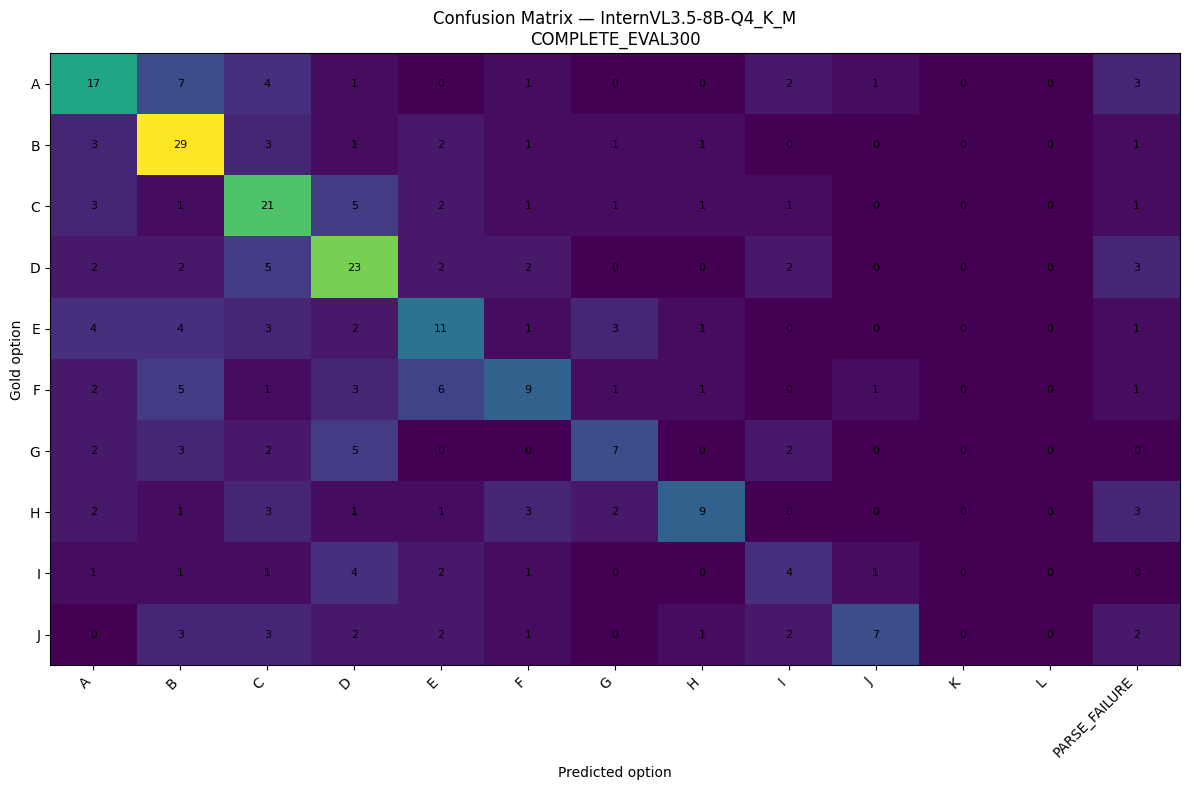

In [23]:
if n_valid:
    max_choices_observed = int(results['n_options'].max())
    observed_choice_labels = choice_letters(max_choices_observed)
    labels = observed_choice_labels + ['PARSE_FAILURE']

    cm = confusion_matrix(yt, yp, labels=labels)

    # Gold labels occupy only rows actually present in the dataset.
    gold_labels_present = [
        label for label in observed_choice_labels
        if label in set(yt)
    ]
    row_indices = [labels.index(label) for label in gold_labels_present]
    cm_display = cm[row_indices, :]

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(cm_display, aspect='auto')

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticks(range(len(gold_labels_present)))
    ax.set_yticklabels(gold_labels_present)

    ax.set_xlabel('Predicted option')
    ax.set_ylabel('Gold option')
    ax.set_title(f'Confusion Matrix — {MODEL}\n{status}')

    for i in range(cm_display.shape[0]):
        for j in range(cm_display.shape[1]):
            ax.text(
                j, i, str(cm_display[i, j]),
                ha='center', va='center', fontsize=8
            )

    fig.tight_layout()
    fig.savefig(
        PLOTS_DIR / 'confusion_matrix.png',
        dpi=180,
        bbox_inches='tight',
    )
    plt.show()

# 19. Two-stage runtime, throughput, token, and output-length metrics


In [24]:
def num(series):
    return pd.to_numeric(series, errors="coerce")


def safe_sum(frame, column):
    return float(num(frame[column]).fillna(0).sum()) if len(frame) and column in frame else 0.0


answer_prompt_tokens = safe_sum(results, "prompt_tokens")
answer_completion_tokens = safe_sum(results, "completion_tokens")
answer_total_tokens = safe_sum(results, "total_tokens")
answer_latency_s = safe_sum(results, "latency_s")
plan_prompt_tokens = safe_sum(plan_results, "prompt_tokens")
plan_completion_tokens = safe_sum(plan_results, "completion_tokens")
plan_total_tokens = safe_sum(plan_results, "total_tokens")
plan_latency_s = safe_sum(plan_results, "latency_s")

eff = {
    "successful_plan_calls": int(n_plan_valid),
    "successful_final_answer_calls": int(n_valid),
    "successful_calls_total": int(n_plan_valid + n_valid),
    "plan_prompt_tokens": plan_prompt_tokens,
    "plan_completion_tokens": plan_completion_tokens,
    "plan_total_tokens": plan_total_tokens,
    "final_answer_prompt_tokens": answer_prompt_tokens,
    "final_answer_completion_tokens": answer_completion_tokens,
    "final_answer_total_tokens": answer_total_tokens,
    "p3_total_prompt_tokens": plan_prompt_tokens + answer_prompt_tokens,
    "p3_total_completion_tokens": plan_completion_tokens + answer_completion_tokens,
    "p3_total_tokens": plan_total_tokens + answer_total_tokens,
    "plan_successful_latency_s": plan_latency_s,
    "final_answer_successful_latency_s": answer_latency_s,
    "p3_successful_latency_s": plan_latency_s + answer_latency_s,
    "p3_total_tokens_per_completed_item": (
        (plan_total_tokens + answer_total_tokens) / n_valid if n_valid else np.nan
    ),
    "plan_truncation_rate": float(plan_results["truncated"].mean()) if n_plan_valid else np.nan,
    "plan_answer_leakage_rate": (
        float(plan_results["plan_answer_leakage_detected"].mean())
        if n_plan_valid else np.nan
    ),
    "final_answer_truncation_rate": float(results["truncated"].mean()) if n_valid else np.nan,
    "mean_plan_completion_tokens": (
        float(num(plan_results["completion_tokens"]).mean()) if n_plan_valid else np.nan
    ),
    "mean_final_answer_completion_tokens": (
        float(num(results["completion_tokens"]).mean()) if n_valid else np.nan
    ),
}
display(pd.DataFrame([eff]).T.rename(columns={0: "value"}).round(5))


,value
successful_plan_calls,3.000000e+02
successful_final_answer_calls,3.000000e+02
successful_calls_total,6.000000e+02
plan_prompt_tokens,4.167210e+05
plan_completion_tokens,2.141450e+05
plan_total_tokens,6.308660e+05
final_answer_prompt_tokens,6.453020e+05
final_answer_completion_tokens,2.275740e+05
final_answer_total_tokens,8.728760e+05
p3_total_prompt_tokens,1.062023e+06


# 20. Latency and completion-token distributions


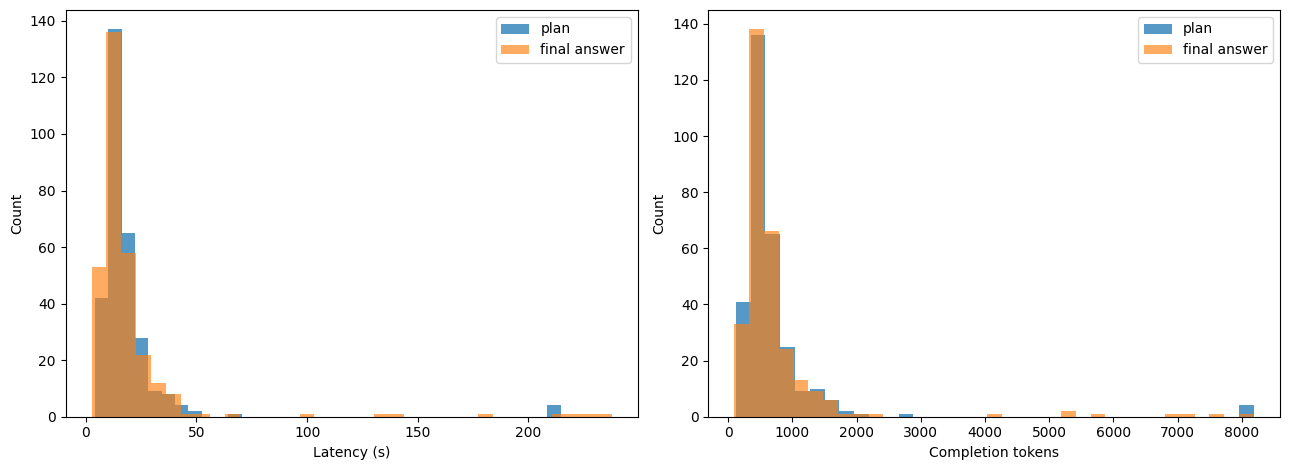

In [25]:
if n_plan_valid or n_valid:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    if n_plan_valid:
        axes[0].hist(num(plan_results["latency_s"]).dropna(), bins=35, alpha=.75, label="plan")
        axes[1].hist(num(plan_results["completion_tokens"]).dropna(), bins=35, alpha=.75, label="plan")
    if n_valid:
        axes[0].hist(num(results["latency_s"]).dropna(), bins=35, alpha=.65, label="final answer")
        axes[1].hist(num(results["completion_tokens"]).dropna(), bins=35, alpha=.65, label="final answer")
    axes[0].set_xlabel("Latency (s)")
    axes[0].set_ylabel("Count")
    axes[0].legend()
    axes[1].set_xlabel("Completion tokens")
    axes[1].set_ylabel("Count")
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "latency_completion_distributions.png", dpi=180)
    plt.show()


# 21. Subject, domain, difficulty, image-type and image-count analyses


In [26]:
DOMAIN={'Art and Design':['Art','Art_Theory','Design','Music'],'Business':['Accounting','Economics','Finance','Manage','Marketing'],
 'Science':['Biology','Chemistry','Geography','Math','Physics'],'Health and Medicine':['Basic_Medical_Science','Clinical_Medicine','Diagnostics_and_Laboratory_Medicine','Pharmacy','Public_Health'],
 'Humanities and Social Science':['History','Literature','Sociology','Psychology'],'Tech and Engineering':['Agriculture','Architecture_and_Engineering','Computer_Science','Electronics','Energy_and_Power','Materials','Mechanical_Engineering']}
S2D={s:d for d,ss in DOMAIN.items() for s in ss}
def group_acc(df,col): return df.groupby(col,dropna=False).agg(n=('sample_id','size'),correct=('strict_correct','sum'),accuracy=('strict_correct','mean'),mean_latency_s=('latency_s','mean'),mean_completion_tokens=('completion_tokens','mean')).reset_index()
if n_valid:
    results['domain']=results['subject'].map(S2D).fillna('Other/Unmapped')
    subject=group_acc(results,'subject'); domain=group_acc(results,'domain'); diff=group_acc(results,'topic_difficulty'); imgt=group_acc(results,'img_type'); imgc=group_acc(results,'image_count')
    subject.to_csv(SUBJECT_CSV,index=False); domain.to_csv(DOMAIN_CSV,index=False); diff.to_csv(DIFF_CSV,index=False); imgt.to_csv(IMGTYPE_CSV,index=False); imgc.to_csv(IMGCOUNT_CSV,index=False)
    print('Domain'); display(domain.round(4)); print('Difficulty'); display(diff.round(4)); print('Image count'); display(imgc.round(4)); print('Subject'); display(subject.round(4))

Domain


,domain,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,Art and Design,40,19,0.4750,11.7789,451.3750
1,Business,50,28,0.5600,21.8132,809.5600
2,Health and Medicine,50,22,0.4400,21.1373,805.2600
3,Humanities and Social Science,40,22,0.5500,12.4677,478.5250
4,Science,50,21,0.4200,20.5821,796.6200
5,Tech and Engineering,70,25,0.3571,27.0846,997.2286


Difficulty


,topic_difficulty,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,Easy,88,47,0.5341,18.8738,708.7727
1,Hard,88,31,0.3523,20.4054,791.1364
2,Medium,124,59,0.4758,20.8536,770.8226


Image count


,image_count,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,1,278,122,0.4388,20.6401,777.5971
1,2,12,10,0.8333,15.8276,590.5833
2,3,1,1,1.0000,8.1254,321.0000
3,4,5,1,0.2000,10.8871,420.0000
4,5,4,3,0.7500,12.9925,473.5000


Subject


,subject,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,Accounting,10,6,0.6,36.9367,1268.9
1,Agriculture,10,5,0.5,12.8473,482.8
2,Architecture_and_Engineering,10,6,0.6,45.2219,1585.1
3,Art,10,4,0.4,13.7863,527.6
4,Art_Theory,10,6,0.6,10.6086,398.7
5,Basic_Medical_Science,10,1,0.1,24.0727,946.7
6,Biology,10,1,0.1,48.3164,1850.4
7,Chemistry,10,5,0.5,11.2915,445.3
8,Clinical_Medicine,10,5,0.5,40.5633,1469.9
9,Computer_Science,10,2,0.2,15.6843,599.8


# 22. Answer-position bias diagnostics


,letter,gold_count,predicted_count
0,A,36,36
1,B,42,56
2,C,37,46
3,D,41,47
4,E,30,28
5,F,30,20
6,G,21,15
7,H,25,14
8,I,15,13
9,J,23,10


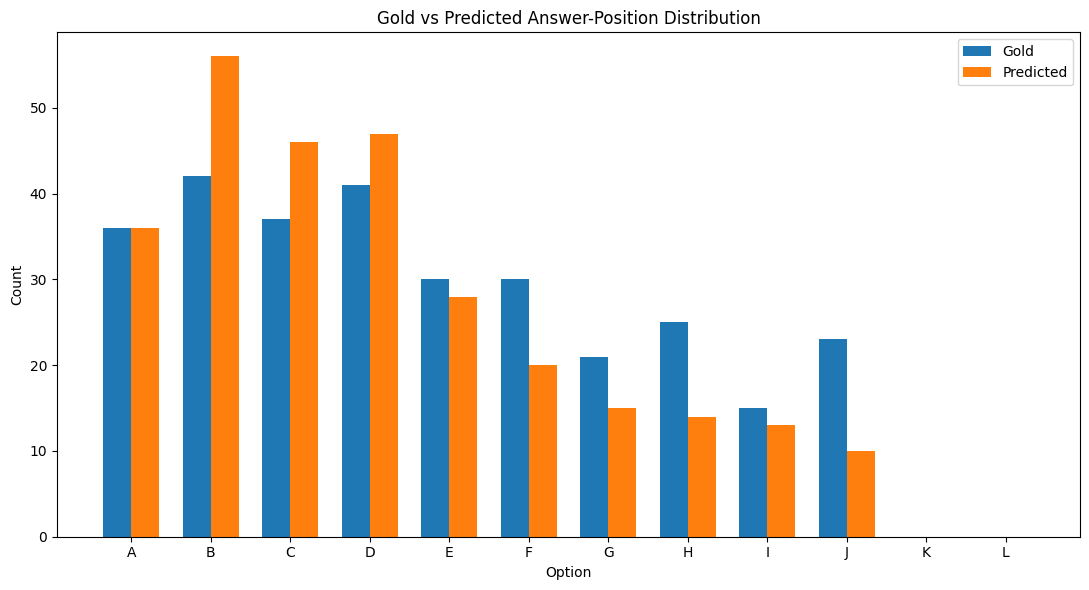

In [27]:
if n_valid:
    position_labels = choice_letters(int(results['n_options'].max()))

    g = results['gold_answer'].value_counts().reindex(position_labels, fill_value=0)
    p = results['strict_prediction'].value_counts().reindex(position_labels, fill_value=0)

    pos = pd.DataFrame({
        'letter': position_labels,
        'gold_count': g.values,
        'predicted_count': p.values,
    })
    display(pos)

    x = np.arange(len(position_labels))
    w = .35
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.bar(x - w/2, pos['gold_count'], w, label='Gold')
    ax.bar(x + w/2, pos['predicted_count'], w, label='Predicted')
    ax.set_xticks(x)
    ax.set_xticklabels(position_labels)
    ax.set_xlabel('Option')
    ax.set_ylabel('Count')
    ax.set_title('Gold vs Predicted Answer-Position Distribution')
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR/'answer_positions.png', dpi=180, bbox_inches='tight')
    plt.show()

# 23. Consolidated paper-ready summary


In [28]:
summary = {
    "analysis_status": status,
    "experiment_id": EXPERIMENT_ID,
    "experiment_signature": EXPERIMENT_SIGNATURE,
    "protocol_version": PROTOCOL_VERSION,
    "model": MODEL,
    "provider": PROVIDER,
    "api_method": API_METHOD,
    "api_version": API_VERSION,
    "sdk_pin": SDK_PIN,
    "dataset_revision": DATASET_REVISION,
    "n_dataset": n_total,
    "n_valid": n_valid,
    "n_missing": n_total - n_valid,
    "coverage": coverage,
    "expected_plan_calls": expected_plan_n,
    "n_plan_valid": n_plan_valid,
    "plan_coverage": plan_coverage,
    "plan_truncation_rate": None if pd.isna(plan_truncation_rate) else float(plan_truncation_rate),
    "plan_answer_leakage_rate": None if pd.isna(plan_answer_leakage_rate) else float(plan_answer_leakage_rate),
    "final_answer_truncation_rate": None if pd.isna(trunc) else float(trunc),
    "strict_format_compliance": None if pd.isna(fmt) else float(fmt),
    "prompt_id": PROMPT_ID,
    "prompt_family": PROMPT_FAMILY,
    "plan_suffix_sha256": PLAN_SUFFIX_SHA256,
    "execution_suffix_sha256": EXECUTION_SUFFIX_SHA256,
    "plan_template_sha256": PLAN_TEMPLATE_SHA256,
    "final_answer_template_sha256": FINAL_ANSWER_TEMPLATE_SHA256,
    "parser_version": PARSER_VERSION,
    "parser_spec_sha256": PARSER_SPEC_SHA256,
    "selection_protocol": SELECTION_PROTOCOL_NAME,
    "selected_ids_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "source_rows": len(source_ds),
    "classification": classification,
    "efficiency": eff,
}
SUMMARY_JSON.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
flat_summary = {
    "analysis_status": status,
    "model": MODEL,
    "provider": PROVIDER,
    "api_method": API_METHOD,
    "dataset_revision": DATASET_REVISION,
    "n_dataset": n_total,
    "n_valid": n_valid,
    "n_missing": n_total - n_valid,
    "coverage": coverage,
    "expected_plan_calls": expected_plan_n,
    "n_plan_valid": n_plan_valid,
    "plan_coverage": plan_coverage,
    **classification,
    **eff,
}
pd.DataFrame([flat_summary]).to_csv(SUMMARY_CSV, index=False)
display(pd.DataFrame([flat_summary]).T.rename(columns={0: "value"}))


,value
analysis_status,COMPLETE_EVAL300
model,InternVL3.5-8B-Q4_K_M
provider,local llama.cpp
api_method,OpenAI-compatible /v1/chat/completions
dataset_revision,563f3e84bb3b90893083a1f039cfa13077f2302b
n_dataset,300
n_valid,300
n_missing,0
coverage,1.0
expected_plan_calls,300


# 24. Professional qualitative audit viewer


In [29]:
def br(x): return html.escape(str(x or "")).replace("\n", "<br>")
if GENERATE_HTML_AUDIT and n_valid:
    cards = []
    for _, r in results.sort_values("execution_order").iterrows():
        imgs = "".join(
            f'<img src="{html.escape(p)}" style="max-width:420px;max-height:320px;margin:6px;border:1px solid #ddd">'
            for p in str(r["image_files"]).split(";") if p
        )
        opts = json.loads(r["options_json"])
        ol = '<ol type="A">' + "".join(f"<li>{html.escape(str(o))}</li>" for o in opts) + "</ol>"
        verdict = "CORRECT" if bool(r["strict_correct"]) else "WRONG"
        cards.append(f"""<section style="border:1px solid #bbb;padding:16px;margin:18px 0"><h2>{html.escape(str(r['sample_id']))} — {verdict}</h2>
        <p><b>Subject:</b> {html.escape(str(r['subject']))}<br><b>Strict prediction:</b> {html.escape(str(r['strict_prediction']))}<br><b>Gold:</b> {html.escape(str(r['gold_answer']))} — {html.escape(str(r['gold_option_text']))}</p>
        <div>{imgs}</div><h3>Call-1 plan supplied verbatim to call 2</h3><div style="background:#eef6ff;padding:10px">{br(r['plan_text'])}</div><h3>Question</h3><p>{br(r['question'])}</p><h3>Options</h3>{ol}<h3>Call-2 visible response</h3><div style="background:#f6f6f6;padding:10px">{br(r['visible_response'])}</div>
        <h3>Model-provided reasoning field</h3><div style="background:#fafafa;padding:10px">{br(r['reasoning_content'])}</div><h3>Gold explanation — intentionally excluded from inference records</h3><div style="background:#fff9e8;padding:10px">{br(r['gold_explanation'])}</div></section>""")
    doc = f'<!doctype html><html><head><meta charset="utf-8"><title>{EXPERIMENT_ID}</title></head><body style="font-family:Arial;max-width:1200px;margin:auto;padding:20px"><h1>{EXPERIMENT_ID}</h1><p><b>Status:</b> {status}; {n_valid}/{n_total}</p>' + "".join(cards) + "</body></html>"
    AUDIT_HTML.write_text(doc, encoding="utf-8")
    print("Saved", AUDIT_HTML)


Saved /kaggle/working/internvl35_8b_p3_two_call_plan_solve_eval300_MAX8192_CTX16384_localinput_v1/audit_viewer.html


# 25. README_RESULTS.md and final completion gate


In [30]:
def pct(value):
    return "N/A" if value is None or pd.isna(value) else f"{100*float(value):.2f}%"

readme = f"""# {EXPERIMENT_ID}

## Status
**{status}** — final answers {n_valid}/{n_total}; plans {n_plan_valid}/{expected_plan_n}.

## P3 method
- Call 1 receives the complete multimodal question and the exact planning trigger.
- Call 2 receives the complete multimodal question again plus the raw Call-1 plan.
- Only Call 2 is scored.
- Both calls preserve numbered-marker occurrence order.
- Repeated references repeat the same source image at every occurrence.
- Successful Call-1 content is injected verbatim, including truncation or answer leakage.
- P3 is reported as a two-call Plan-and-Solve adaptation.

## Local model/runtime
- model: `{MODEL}` (`{QUANTIZATION}`)
- base model: `{BASE_MODEL}`
- model SHA-256: `{MODEL_SHA_OBSERVED}`
- projector SHA-256: `{MMPROJ_SHA_OBSERVED}`
- llama source commit: `{LLAMA_CPP_COMMIT}`
- llama runtime SHA-256: `{LLAMA_SHA_OBSERVED}`
- input runtime: `{LLAMA_INPUT_PATH}`
- execution runtime: `{LLAMA_BIN}`
- execution is never performed directly from `/kaggle/input`

## Generation — both calls
- temperature `{TEMPERATURE}`; top-p/top-k not sent
- max output tokens `{MAX_TOKENS}` per call
- context size `{CTX_SIZE}`
- seed `{API_SEED}`
- streaming `{STREAM}`
- thinking policy: {THINKING_MODE_POLICY}

## Dataset
- `{DATASET_REPO}` / `{DATASET_CONFIG}` / `{DATASET_SPLIT}`
- revision `{DATASET_REVISION}`
- selected IDs SHA-256 `{SELECTED_IDS_CANONICAL_SHA256}`
- 300 rows, 30 subjects, 10 items per subject

## Prompt hashes
- Call-1 suffix `{PLAN_SUFFIX_SHA256}`
- Call-1 canonical template `{PLAN_TEMPLATE_SHA256}`
- Call-2 suffix `{EXECUTION_SUFFIX_SHA256}`
- Call-2 canonical template `{FINAL_ANSWER_TEMPLATE_SHA256}`

## Scheduling and resume
- request timeout `{REQUEST_TIMEOUT_S}` seconds
- deferred retry timeout `{DEFERRED_REQUEST_TIMEOUT_S}` seconds
- plans and final answers are checkpointed independently
- only missing stages are sent after exact-signature validation
- valid truncated, answer-leaking and parse-failure outputs are retained

## Frozen scoring
- parser `{PARSER_VERSION}`
- parser SHA-256 `{PARSER_SPEC_SHA256}`
- primary outcome: deterministic last-line answer accuracy on Call 2
- no random fallback; truncated final answers are incorrect

## Headline results
- primary answer accuracy: {pct(classification.get('strict_accuracy'))}
- Call-1 plan truncation rate: {pct(plan_truncation_rate)}
- Call-1 answer-leakage rate: {pct(plan_answer_leakage_rate)}
- Call-2 truncation rate: {pct(trunc)}
- total P3 tokens: {eff.get('p3_total_tokens', 'N/A')}

Final results are reportable only when both P3 stages have complete coverage.
"""
README.write_text(readme, encoding="utf-8")
print(readme)


# MMMUPro-Eval300__InternVL3.5-8B-Q4_K_M__P3-TwoCallPlanAndSolve__LocalLlamaCpp__RawPlanInjection__ValidatedTwoStageResume__Temperature0__Seed42__MAX8192__CTX16384

## Status
**COMPLETE_EVAL300** — final answers 300/300; plans 300/300.

## P3 method
- Call 1 receives the complete multimodal question and the exact planning trigger.
- Call 2 receives the complete multimodal question again plus the raw Call-1 plan.
- Only Call 2 is scored.
- Both calls preserve numbered-marker occurrence order.
- Repeated references repeat the same source image at every occurrence.
- Successful Call-1 content is injected verbatim, including truncation or answer leakage.
- P3 is reported as a two-call Plan-and-Solve adaptation.

## Local model/runtime
- model: `InternVL3.5-8B-Q4_K_M` (`Q4_K_M`)
- base model: `OpenGVLab/InternVL3_5-8B`
- model SHA-256: `2809043479b8d3aab30378766c7a2a4bd93eedd97c86efc6d65d627fd680faba`
- projector SHA-256: `212cc090f81ea2981b870186d4b424fae69489a5313a14e52ffdb2e877852389`
- 

In [31]:
# 26. Suggested Methods wording for the P3 experiment

methods = f"""
We evaluated {MODEL} ({QUANTIZATION}) using a two-call Plan-and-Solve
adaptation (P3) on the frozen balanced MMMU-Pro Eval300 cohort. In Call 1, the
complete multimodal multiple-choice problem was followed by the planning trigger:
`{PLAN_SUFFIX}`. The raw visible Call-1 response was checkpointed and inserted
without semantic editing into Call 2. Call 2 received the complete problem and
images again, followed by the stored plan and the frozen execution/final-answer
scaffold. Only Call 2 was scored.

Both calls followed the numbered image-marker occurrence order. Each occurrence
consisted of a semantic label immediately followed by the matching lossless PNG
image. Repeated references repeated the same source image at each occurrence.
Gold answers and reference explanations were never supplied.

The locally attached model, multimodal projector, and llama runtime were verified
by SHA-256. The runtime under `/kaggle/input` was never executed directly; its
verified bytes were always copied to a writable `/kaggle/temp` path, chmod was
applied only to that copy, and SHA-256 was checked again before execution. This
avoids Kaggle read-only and `noexec` mount failures.

Both calls used temperature 0, fixed seed 42, no explicit top-p or top-k,
{MAX_TOKENS} maximum output tokens per call, context size {CTX_SIZE}, and
non-streaming generation. No model-specific `enable_thinking` request parameter was sent to InternVL; llama used `--reasoning off`, and any reasoning-like provider field was treated as diagnostic only.

Ordinary requests used a {REQUEST_TIMEOUT_S}-second timeout. A timeout or local
server failure left the affected P3 stage incomplete; after server recovery, the
missing stage was retried in the deferred pass with a
{DEFERRED_REQUEST_TIMEOUT_S}-second timeout. Plans and final answers were
checkpointed independently. Resume required the exact P3 experiment signature,
prompt hashes, image hashes, occurrence order, and the hash of the injected plan.

A successful HTTP 200 model response was never regenerated based on content
quality, truncation, plan answer leakage, or formatting. Headline accuracy used
frozen parser `{PARSER_VERSION}`, which accepts an answer only from the last
non-empty line and has no random fallback. Results were final only after complete
coverage of both P3 stages.
""".strip()

print(methods)
(WORKDIR / "METHODS_SUGGESTION.txt").write_text(methods + "\n", encoding="utf-8")


We evaluated InternVL3.5-8B-Q4_K_M (Q4_K_M) using a two-call Plan-and-Solve
adaptation (P3) on the frozen balanced MMMU-Pro Eval300 cohort. In Call 1, the
complete multimodal multiple-choice problem was followed by the planning trigger:
`A: Let's first understand the problem and devise a plan to solve the problem.`. The raw visible Call-1 response was checkpointed and inserted
without semantic editing into Call 2. Call 2 received the complete problem and
images again, followed by the stored plan and the frozen execution/final-answer
scaffold. Only Call 2 was scored.

Both calls followed the numbered image-marker occurrence order. Each occurrence
consisted of a semantic label immediately followed by the matching lossless PNG
image. Repeated references repeated the same source image at each occurrence.
Gold answers and reference explanations were never supplied.

The locally attached model, multimodal projector, and llama runtime were verified
by SHA-256. The runtime under `/kaggle/input

2359